# Region6 - All 479 - Primary Include
## Xiaonan Wang
## 09Sep2026

In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(SeuratObject)
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(Matrix)
  library(ggplot2)
})

set.seed(1234)

In [2]:
REGION_ID = "Region_6"

In [3]:
PROJECT_ROOT <- "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium"
PIPELINE_REPO <- file.path(PROJECT_ROOT, "colon_analysis", "YNH_Xenium_Colon")
RUN_LABEL <- "full_notebook_qc_v2"
QC_RUN_ROOT <- file.path(
  PROJECT_ROOT,
  "colon_analysis",
  "colon_qc_outputs",
  "colon_qc_hpc/sections",
  REGION_ID
)
DOWNSTREAM_ROOT <- file.path(
  PROJECT_ROOT,
  "colon_analysis",
  "colon_downstream_outputs",
  RUN_LABEL
)
ANCHOR_ROOT <- file.path(
  DOWNSTREAM_ROOT,
  paste0("03_", REGION_ID, "_Primary479")
)
INPUT_ROOT <- file.path(PROJECT_ROOT, "adipose_data_B2/20260814__101613__260814_Yanan_repeat")

In [79]:
source(file.path(PIPELINE_REPO, "R", "source.R"))

In [5]:
assert_path_within(PROJECT_ROOT, QC_RUN_ROOT)
assert_path_within(PROJECT_ROOT, DOWNSTREAM_ROOT)
dir.create(DOWNSTREAM_ROOT, recursive = TRUE, showWarnings = FALSE)
assert_path_within(PROJECT_ROOT, ANCHOR_ROOT)
dir.create(ANCHOR_ROOT, recursive = TRUE, showWarnings = FALSE)

## Step1 - Create Seurat Obj

In [6]:
region_info <- discover_one_section(
  input_root = INPUT_ROOT,
  region_id = REGION_ID
)
REGION_XENIUM_DIR <- region_info$region_dir

In [7]:
list.files(
  REGION_XENIUM_DIR,
  recursive = FALSE
)

[1] "analysis"                     "analysis_summary.html"       
 [3] "analysis.zarr.zip"            "aux_outputs"                 
 [5] "cell_boundaries.csv.gz"       "cell_boundaries.parquet"     
 [7] "cell_feature_matrix"          "cell_feature_matrix.h5"      
 [9] "cell_feature_matrix.zarr.zip" "cells.csv.gz"                
[11] "cells.parquet"                "cells.zarr.zip"              
[13] "experiment.xenium"            "gene_panel.json"             
[15] "metrics_summary.csv"          "morphology_focus"            
[17] "morphology.ome.tif"           "nucleus_boundaries.csv.gz"   
[19] "nucleus_boundaries.parquet"   "transcripts.parquet"         
[21] "transcripts.zarr.zip"

In [8]:
region_spatial <- create_spatial_seurat_from_xenium(
  xenium_dir = REGION_XENIUM_DIR,
  project = REGION_ID,
  assay = "Xenium",
  fov = "fov",
  include_cell_segmentation = TRUE,
  include_nucleus_segmentation = TRUE
)

Reading Xenium output directly from:

  /dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data_B2/20260814__101613__260814_Yanan_repeat/output-XETG00205__0104842__Region_6__20260814__101700

Reading cell_feature_matrix.h5 ...

Genome matrix has multiple modalities, returning a list of matrices for this genome

Read10X returned feature types: Gene Expression, Negative Control Probe, Negative Control Codeword, Unassigned Codeword

Native matrix: 479 features × 138,752 cells

Reading cells.parquet ...

Matrix/metadata overlapping cells: 138,752

Warning message:
“Setting row names on a tibble is deprecated.”
Warning message:
“No cell overlap between new meta data and Seurat object”
Creating cell segmentation: 3,465,186 vertices

Creating nucleus segmentation: 3,374,527 vertices



Created native Xenium spatial Seurat object: Region_6

  Cells: 138,752

  Genes: 479

  FOV: fov

  Boundaries: centroids, segmentation, nucleus_segmentation



In [9]:
region_spatial

An object of class Seurat 
479 features across 138752 samples within 1 assay 
Active assay: Xenium (479 features, 0 variable features)
 1 layer present: counts
 1 spatial field of view present: fov

In [10]:
head(region_spatial@meta.data)

,orig.ident,nCount_Xenium,nFeature_Xenium
,<fct>,<dbl>,<int>
aaaacdfg-1,Region_6,1516,122
aaaaoogd-1,Region_6,323,84
aaacbpgn-1,Region_6,605,92
aaacbpgp-1,Region_6,535,101
aaacfnak-1,Region_6,144,56
aaacjbbh-1,Region_6,867,108


In [11]:
dim(region_spatial@meta.data)

[1] 138752      3

In [12]:
mask_file <- file.path(
  QC_RUN_ROOT,
  "cell_qc_metadata.tsv.gz"
)

stopifnot(file.exists(mask_file))

masks <- read.delim(
  mask_file,
  stringsAsFactors = FALSE,
  check.names = FALSE
)

dim(masks)

[1] 138752     34

In [13]:
identical(masks$cell_id, colnames(region_spatial))

[1] TRUE

In [14]:
region_spatial <- add_masks_to_seurat(
  object = region_spatial,
  masks = masks,
  overwrite = FALSE
)

Seurat cells: 138,752

Matched to masks: 138,752

Unmatched Seurat cells: 0

Skipping existing metadata columns: nCount_Xenium, nFeature_Xenium

Added 31 metadata columns.

Metadata dimensions: 138752 × 34



In [15]:
head(region_spatial@meta.data, n=2)

,orig.ident,nCount_Xenium,nFeature_Xenium,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,⋯,qc_review_flag,primary_include,strict_include,hotspot_review_cell,hotspot_sensitivity_include,section_status,mask_rule_primary,mask_rule_strict,mask_rule_hotspot_sensitivity,provenance
,<fct>,<dbl>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>
aaaacdfg-1,Region_6,1516,122,1168.222,1525.221,1516,0,0,0,0,⋯,TRUE,FALSE,FALSE,FALSE,FALSE,QC_EVIDENCE_PENDING,nFeature_Xenium > 5 AND nFeature_Xenium < 200 AND nCount_Xenium > 10 AND nCount_Xenium < 1000,primary_include AND NOT qc_review_flag,primary_include AND NOT Region_3 morphology-review hotspot cell,colon_qc_hpc::FULL_HPC
aaaaoogd-1,Region_6,323,84,1177.287,1534.339,323,0,0,0,0,⋯,FALSE,TRUE,TRUE,FALSE,TRUE,QC_EVIDENCE_PENDING,nFeature_Xenium > 5 AND nFeature_Xenium < 200 AND nCount_Xenium > 10 AND nCount_Xenium < 1000,primary_include AND NOT qc_review_flag,primary_include AND NOT Region_3 morphology-review hotspot cell,colon_qc_hpc::FULL_HPC


In [16]:
colnames(region_spatial@meta.data)

[1] "orig.ident"                    "nCount_Xenium"                
 [3] "nFeature_Xenium"               "x_centroid"                   
 [5] "y_centroid"                    "transcript_counts"            
 [7] "control_probe_counts"          "genomic_control_counts"       
 [9] "control_codeword_counts"       "unassigned_codeword_counts"   
[11] "deprecated_codeword_counts"    "total_counts"                 
[13] "cell_area"                     "nucleus_area"                 
[15] "nucleus_count"                 "segmentation_method"          
[17] "region_id"                     "control_fraction_cell"        
[19] "nucleus_missing_flag"          "multiple_nuclei_flag"         
[21] "cell_area_outlier_flag"        "high_control_flag"            
[23] "segmentation_multiplet_flag"   "qc_core_pass"                 
[25] "qc_review_flag"                "primary_include"              
[27] "strict_include"                "hotspot_review_cell"          
[29] "hotspot_sensitivity_include"   "section_status"               
[31] "mask_rule_primary"             "mask_rule_strict"             
[33] "mask_rule_hotspot_sensitivity" "provenance"

In [17]:
table(region_spatial$primary_include, region_spatial$qc_core_pass)

       
         FALSE   TRUE
  FALSE   5557      0
  TRUE       0 133195

In [18]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_all.rds")))

## Step2 - Define gene set info

In [19]:
# EOS features
EOS_GENE_SET_PATH <- file.path(
  PIPELINE_REPO,
  "config",
  "eos_gene_sets.tsv"
)

eos_gene_sets <- read.delim(
  EOS_GENE_SET_PATH,
  stringsAsFactors = FALSE
)

In [20]:
# Identity-transfer panel:
# complete 479-gene panel minus short-/long-lived Eos state genes.
# This retains the original 379 mMulti genes plus the 7 common Eos identity genes.

eos_state_genes <- unique(
  eos_gene_sets$gene[
    eos_gene_sets$gene_set %in% c("short_lived", "long_lived")
  ]
)

raw_panel_genes <- rownames(region_spatial)

identity_panel_genes <- setdiff(
  raw_panel_genes,
  eos_state_genes
)

cat("Raw panel genes:", length(raw_panel_genes), "\n")
cat("Eos state genes excluded:", length(intersect(raw_panel_genes, eos_state_genes)), "\n")
cat("Identity panel genes:", length(identity_panel_genes), "\n")

stopifnot(length(raw_panel_genes) == 479L)


Raw panel genes: 479 
Eos state genes excluded: 93 
Identity panel genes: 386 


In [21]:
FIX_GENESET = raw_panel_genes

## Step3 - Subset cells

In [22]:
region_spatial = readRDS(file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_all.rds")))

In [23]:
colnames(region_spatial@meta.data)

[1] "orig.ident"                    "nCount_Xenium"                
 [3] "nFeature_Xenium"               "x_centroid"                   
 [5] "y_centroid"                    "transcript_counts"            
 [7] "control_probe_counts"          "genomic_control_counts"       
 [9] "control_codeword_counts"       "unassigned_codeword_counts"   
[11] "deprecated_codeword_counts"    "total_counts"                 
[13] "cell_area"                     "nucleus_area"                 
[15] "nucleus_count"                 "segmentation_method"          
[17] "region_id"                     "control_fraction_cell"        
[19] "nucleus_missing_flag"          "multiple_nuclei_flag"         
[21] "cell_area_outlier_flag"        "high_control_flag"            
[23] "segmentation_multiplet_flag"   "qc_core_pass"                 
[25] "qc_review_flag"                "primary_include"              
[27] "strict_include"                "hotspot_review_cell"          
[29] "hotspot_sensitivity_include"   "section_status"               
[31] "mask_rule_primary"             "mask_rule_strict"             
[33] "mask_rule_hotspot_sensitivity" "provenance"

In [24]:
options(repr.plot.width=8, repr.plot.height=8)

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


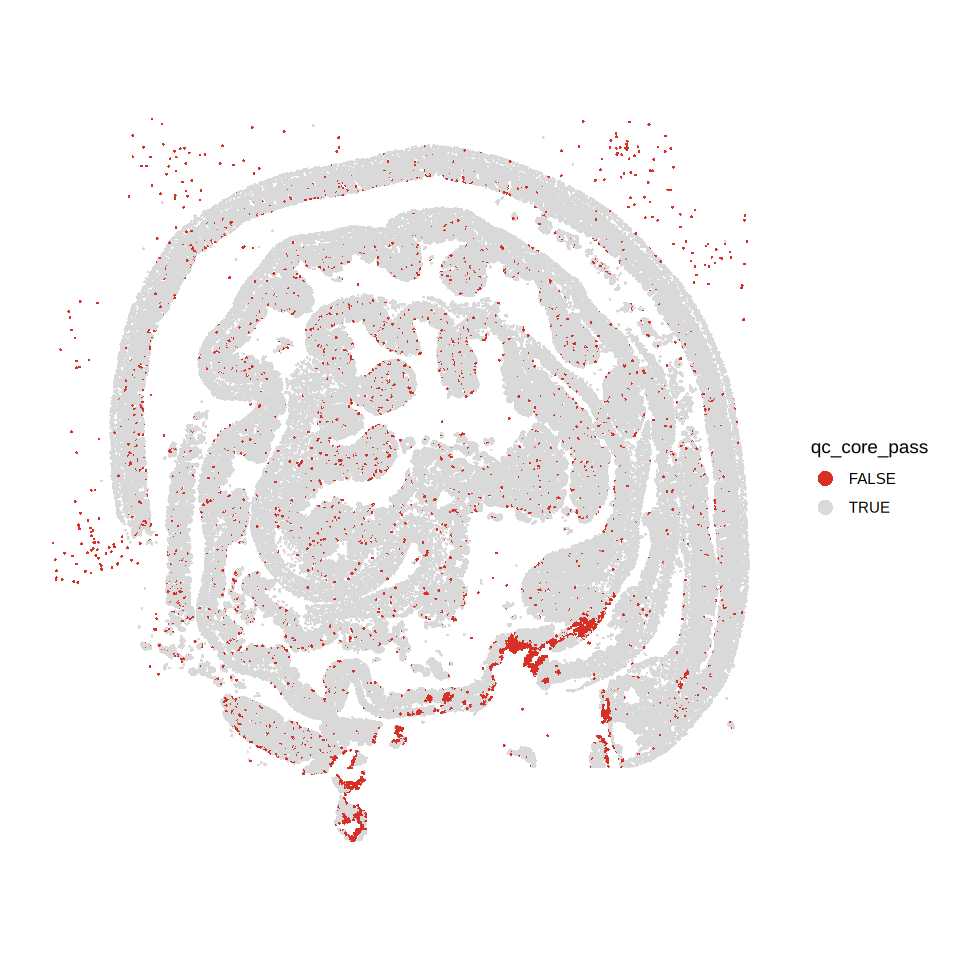

In [25]:
ImageDimPlot(
  region_spatial,
  fov = "fov",
  group.by = c('qc_core_pass'),
  flip_xy = FALSE,
  dark.background = FALSE,
  cols = c(
    "FALSE" = "#D73027", 
    "TRUE"  = "#D9D9D9"  
  )
)

In [26]:
flag_cols <- c(
  "high_control_flag",
  "segmentation_multiplet_flag",
  "nucleus_missing_flag",
  "multiple_nuclei_flag",
  "cell_area_outlier_flag"
)

sapply(
  masks[, flag_cols, drop = FALSE],
  function(x) {
    c(
      n = sum(x %in% TRUE, na.rm = TRUE),
      pct = 100 * mean(x %in% TRUE, na.rm = TRUE)
    )
  }
)

,high_control_flag,segmentation_multiplet_flag,nucleus_missing_flag,multiple_nuclei_flag,cell_area_outlier_flag
n,25.00000000,7075.000000,10744.000000,6704.000000,2187.000000
pct,0.01801776,5.099026,7.743312,4.831642,1.576193


In [27]:
table(!region_spatial$qc_core_pass, region_spatial$segmentation_multiplet_flag)

       
         FALSE   TRUE
  FALSE 127948   5247
  TRUE    3729   1828

In [28]:
region_spatial$primary_include_revised <-
  (masks$qc_core_pass %in% TRUE) &
  !(masks$high_control_flag %in% TRUE) &
  !(masks$segmentation_multiplet_flag %in% TRUE)

In [29]:
table(region_spatial$primary_include_revised)


 FALSE   TRUE 
 10817 127935 

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


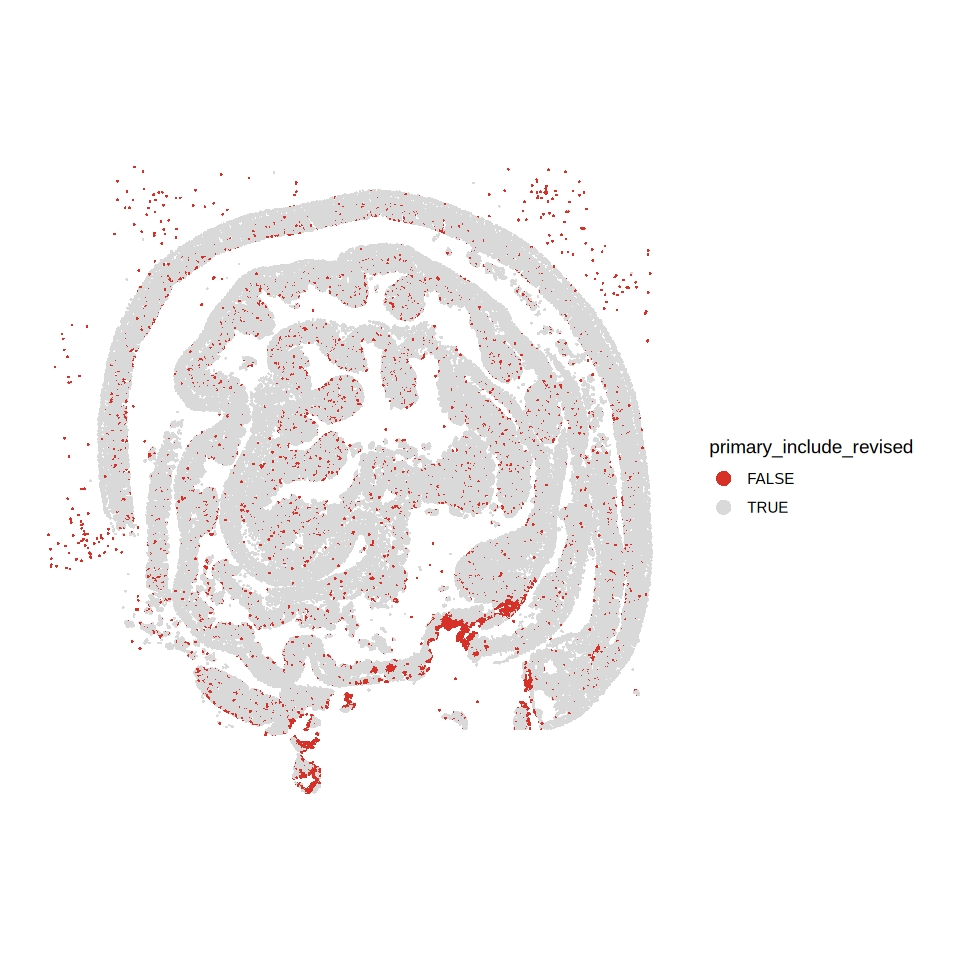

In [30]:
ImageDimPlot(
  region_spatial,
  fov = "fov",
  group.by = c('primary_include_revised'),
  flip_xy = FALSE,
  dark.background = FALSE,
  cols = c(
    "FALSE" = "#D73027", 
    "TRUE"  = "#D9D9D9"  
  )
)

In [31]:
region_spatial <- subset(
  region_spatial,
  subset = primary_include_revised == TRUE
)

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


In [32]:
region_spatial

An object of class Seurat 
479 features across 127935 samples within 1 assay 
Active assay: Xenium (479 features, 0 variable features)
 1 layer present: counts
 1 spatial field of view present: fov

In [33]:
dim(region_spatial@meta.data)

[1] 127935     35

In [34]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

In [35]:
# Normalisation - better use lognormlize rather than SCTransform
DefaultAssay(region_spatial) <- "Xenium"

region_spatial <- NormalizeData(
  region_spatial,
  assay = "Xenium",
  normalization.method = "LogNormalize",
  scale.factor = 10000,
  verbose = FALSE
)

In [36]:
region_spatial

An object of class Seurat 
479 features across 127935 samples within 1 assay 
Active assay: Xenium (479 features, 0 variable features)
 2 layers present: counts, data
 1 spatial field of view present: fov

In [37]:
# only use the cell type genes for PCA as key features
region_spatial <- ScaleData(
  region_spatial,
  assay = "Xenium",
  features = FIX_GENESET,
  verbose = FALSE
)

region_spatial <- RunPCA(
  region_spatial,
  assay = "Xenium",
  features = FIX_GENESET,
  npcs = 30,
  seed.use = 1234,
  verbose = FALSE
)

In [38]:
region_spatial

An object of class Seurat 
479 features across 127935 samples within 1 assay 
Active assay: Xenium (479 features, 0 variable features)
 3 layers present: counts, data, scale.data
 1 dimensional reduction calculated: pca
 1 spatial field of view present: fov

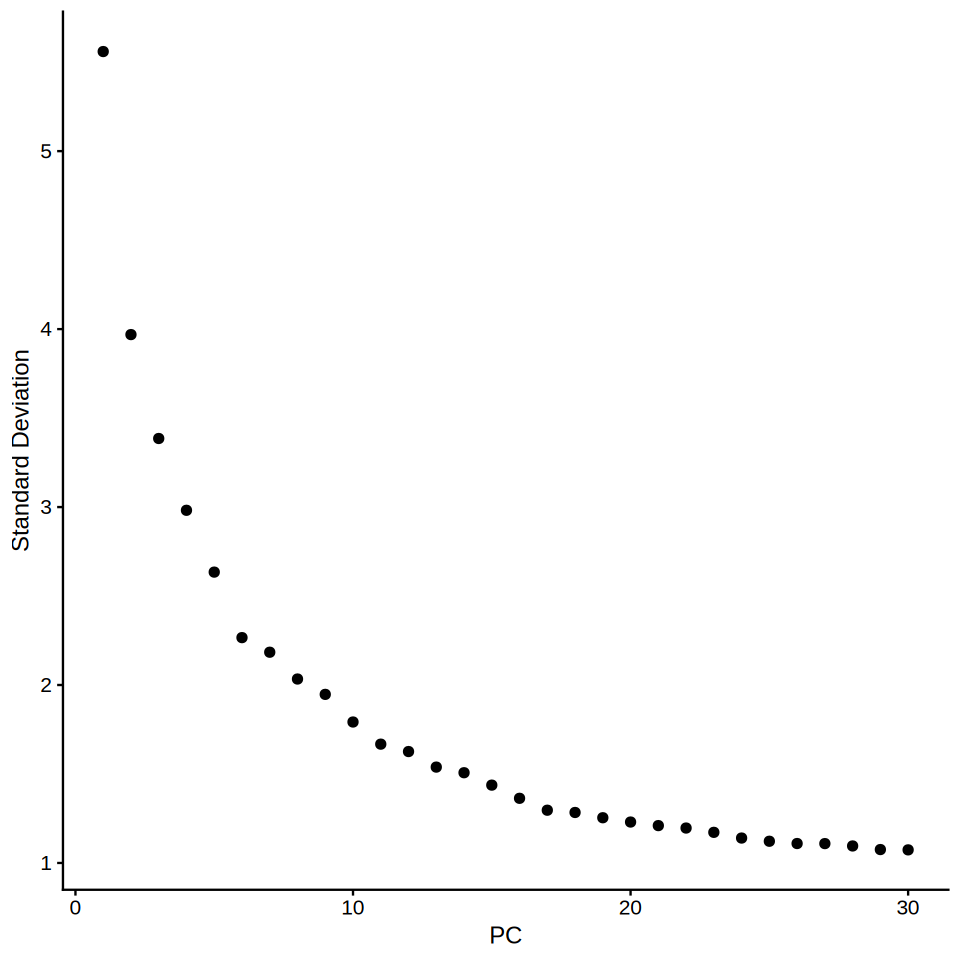

In [39]:
ElbowPlot(
  region_spatial,
  ndims = 30
)

In [40]:
options(repr.plot.width=12, repr.plot.height=12)

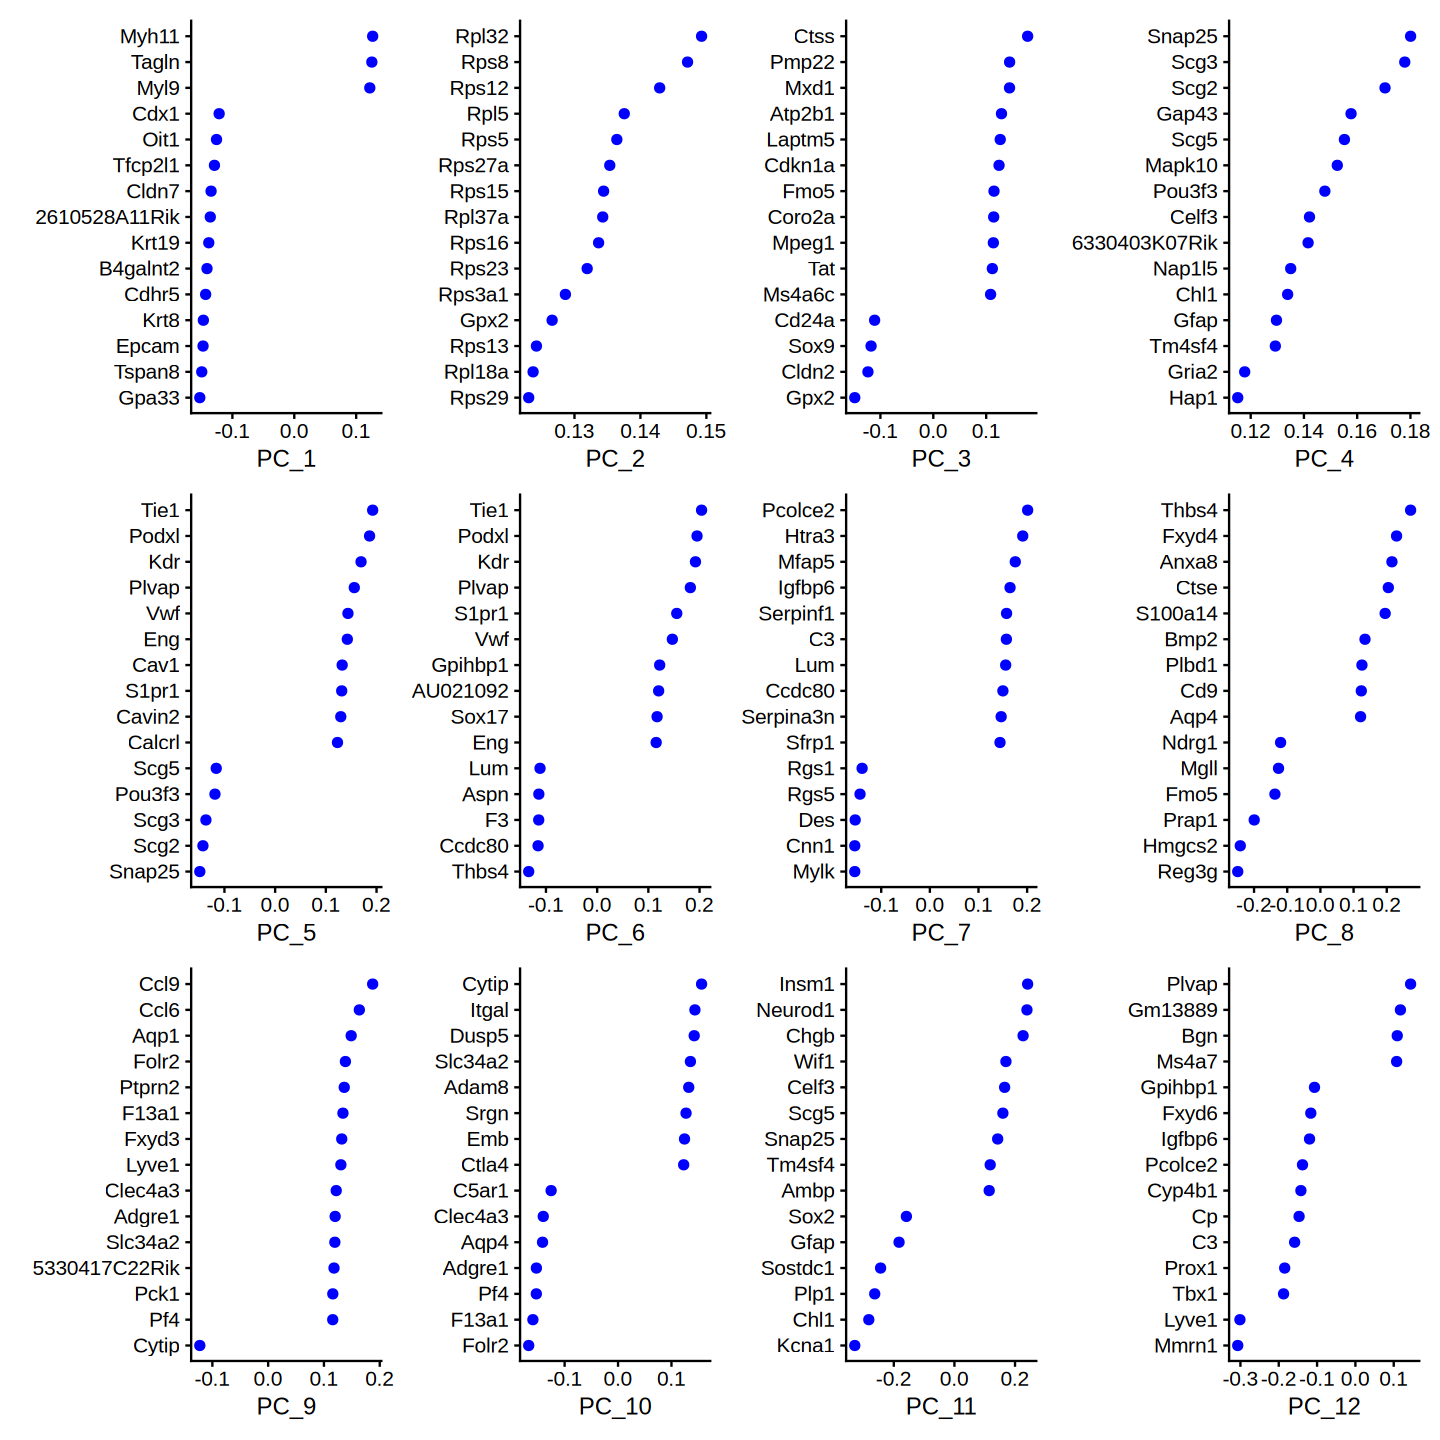

In [41]:
VizDimLoadings(
  region_spatial,
  dims = 1:12,
  reduction = "pca",
  nfeatures = 15
)

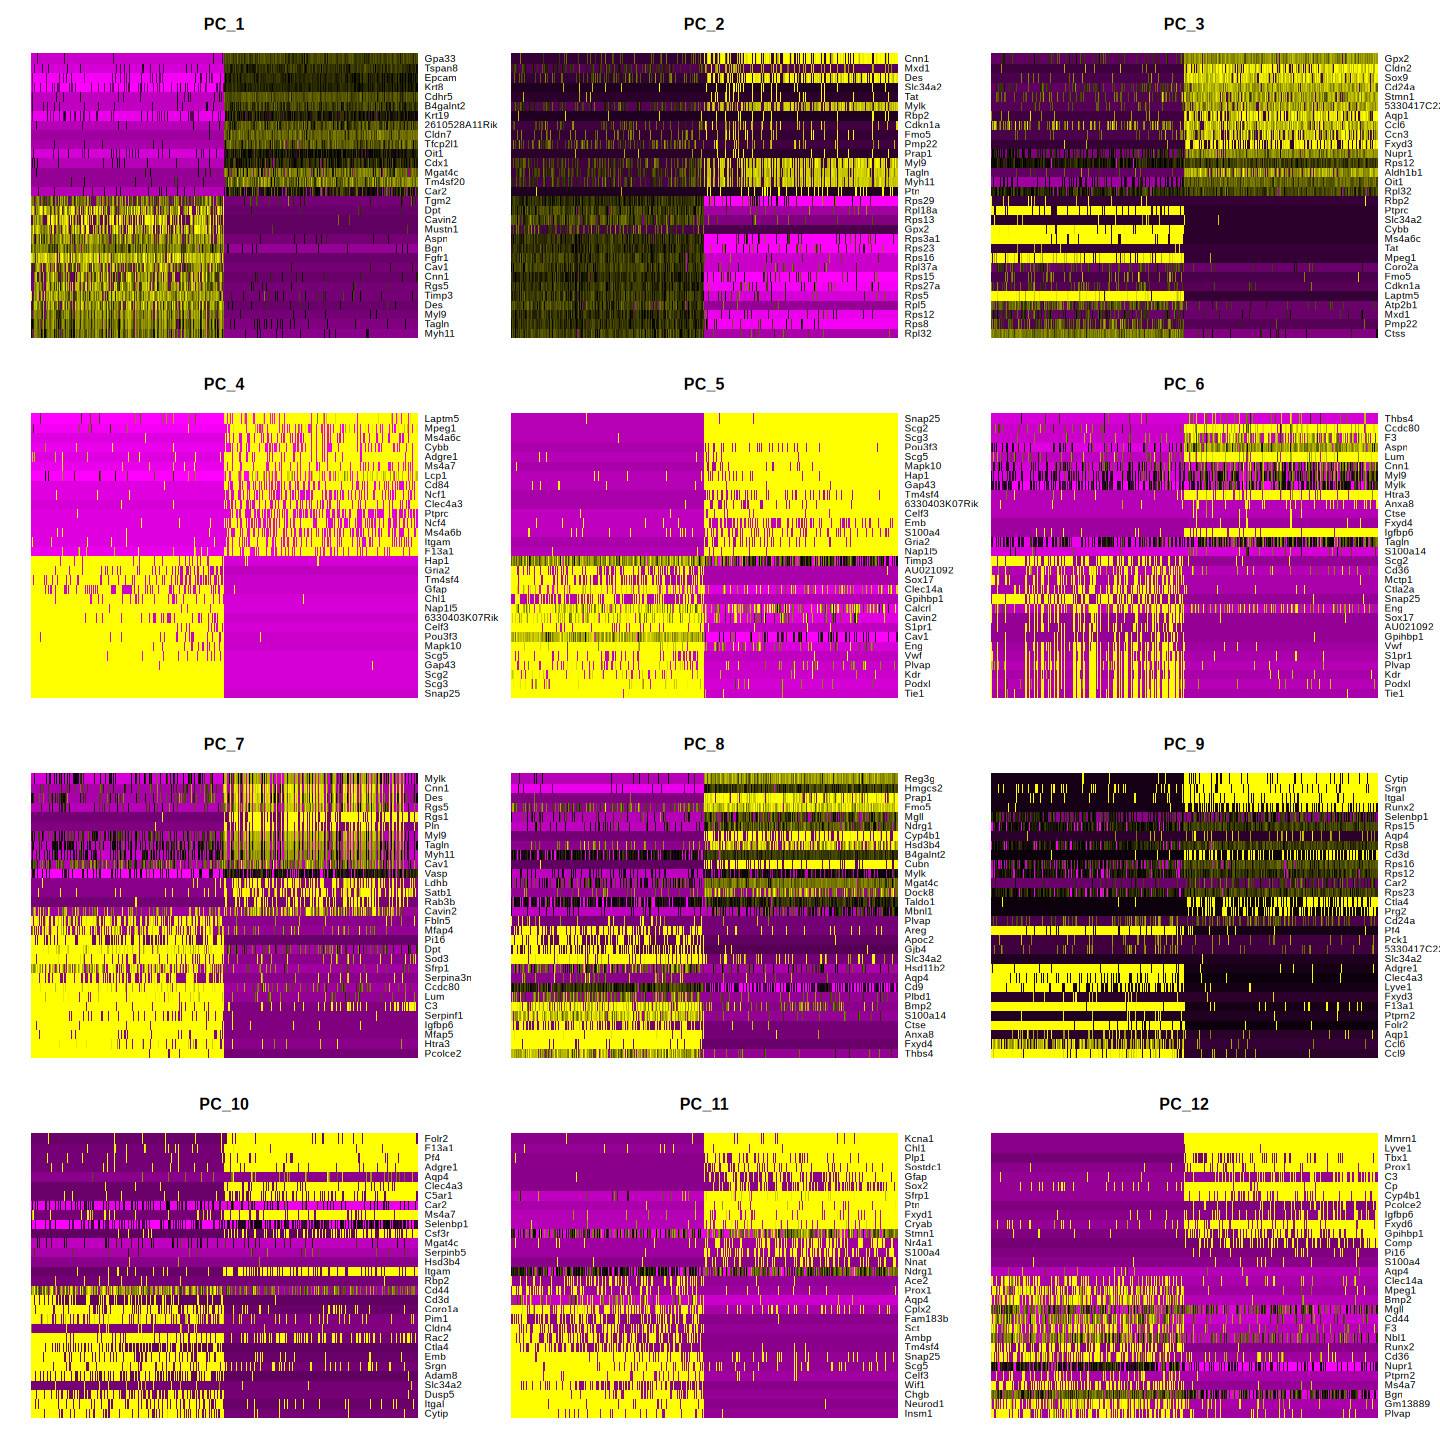

In [42]:
DimHeatmap(
  region_spatial,
  dims = 1:12,
  cells = 1000,
  balanced = TRUE
)

In [43]:
pcs <- Embeddings(
  region_spatial,
  reduction = "pca"
)

qc_vars <- c(
  "nCount_Xenium",
  "nFeature_Xenium",
  "cell_area"
)

qc_vars <- qc_vars[
  qc_vars %in% colnames(region_spatial@meta.data)
]

In [44]:
pc_qc_cor <- sapply(
  qc_vars,
  function(v) {
    apply(
      pcs,
      2,
      function(pc) {
        cor(
          pc,
          region_spatial@meta.data[[v]],
          method = "spearman",
          use = "pairwise.complete.obs"
        )
      }
    )
  }
)

round(pc_qc_cor, 3)

,nCount_Xenium,nFeature_Xenium,cell_area
PC_1,-0.531,-0.358,-0.211
PC_2,0.382,0.599,0.267
PC_3,0.118,0.250,0.092
PC_4,0.644,0.638,0.532
PC_5,0.384,0.406,0.330
PC_6,-0.272,-0.266,-0.245
PC_7,-0.297,-0.255,-0.216
PC_8,-0.262,-0.206,-0.210
PC_9,0.159,0.114,0.180
PC_10,-0.009,-0.018,0.034


In [45]:
dims_use <- 1:30

In [46]:
region_spatial <- FindNeighbors(
  region_spatial,
  reduction = "pca",
  dims = dims_use,
  k.param = 20,
  graph.name = c(
    "Xenium_nn_PC30",
    "Xenium_snn_PC30"
  ),
  verbose = FALSE
)

In [47]:
region_spatial <- RunUMAP(
  region_spatial,
  reduction = "pca",
  dims = dims_use,
  reduction.name = "umap_PC30",
  seed.use = 1234,
  verbose = FALSE
)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


In [48]:
resolutions <- c(
  0.7,
  0.8,
  1.0,
  1.2
)

for (res in resolutions) {
  print(res)
  region_spatial <- FindClusters(
    region_spatial,
    graph.name = "Xenium_snn_PC30",
    algorithm = 4,
    resolution = res,
    cluster.name = paste0(
      "cluster_res_",
      gsub("\\.", "_", res)
    ),
    random.seed = 1234,
    verbose = FALSE
  )
}

[1] 0.7
[1] 0.8
[1] 1
[1] 1.2


In [49]:
options(repr.plot.width=12, repr.plot.height=8)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



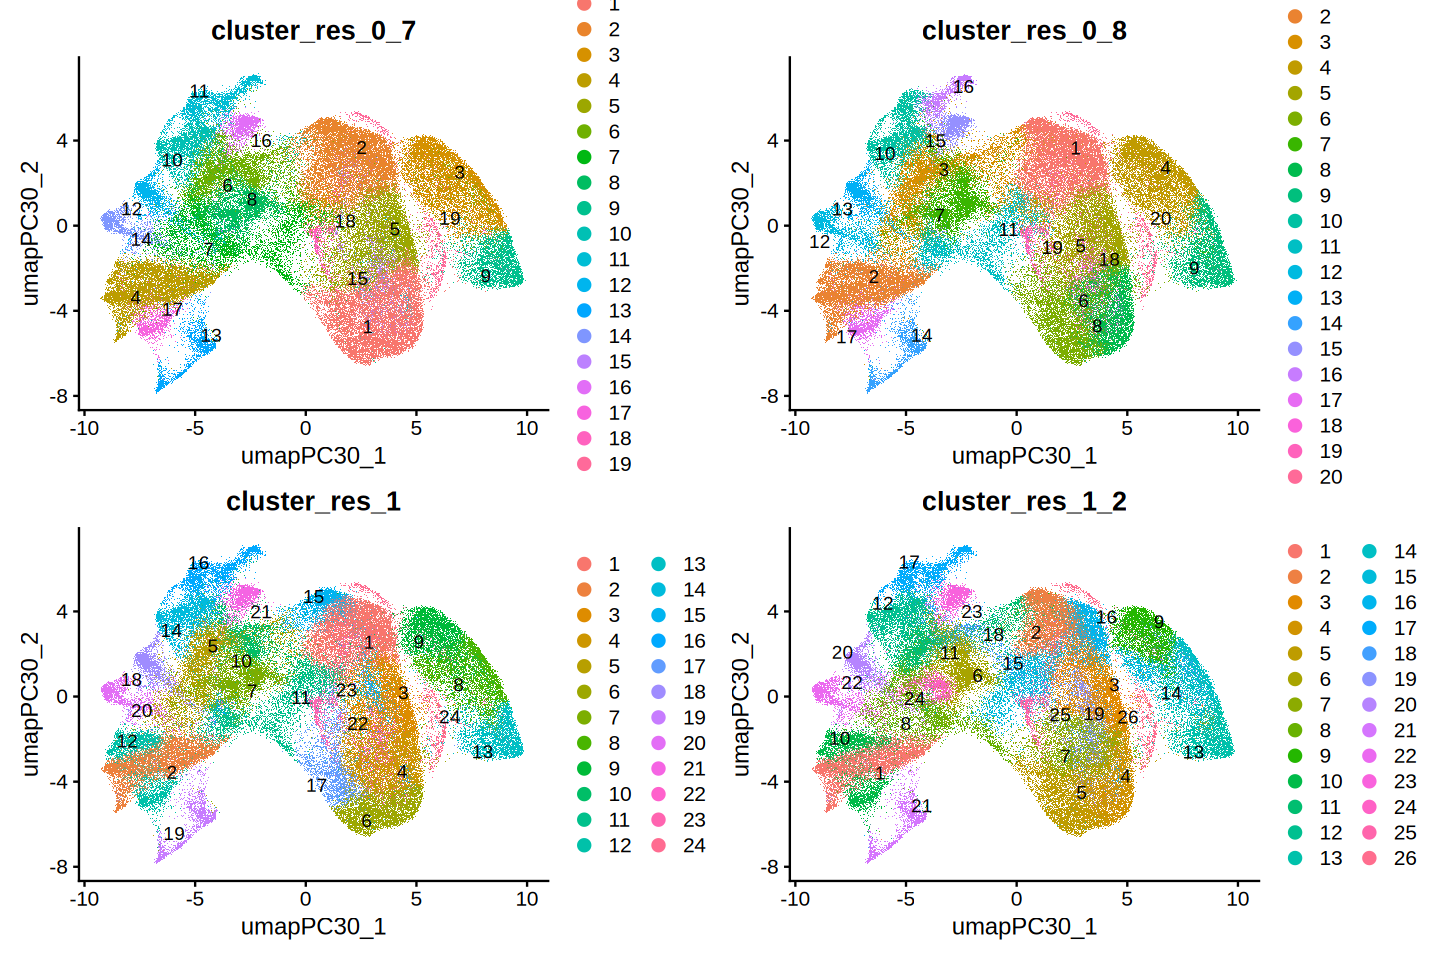

In [50]:
DimPlot(
  region_spatial,
  reduction = "umap_PC30",
  group.by = c(
    "cluster_res_0_7",
    "cluster_res_0_8",
    "cluster_res_1",
    "cluster_res_1_2"
  ),
  label = TRUE,
  repel = TRUE,
  ncol = 2
)

In [51]:
region_spatial

An object of class Seurat 
479 features across 127935 samples within 1 assay 
Active assay: Xenium (479 features, 0 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap_PC30
 1 spatial field of view present: fov

In [52]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

## Step4 - Have a brief understanding of the cell types

In [53]:
region_spatial = readRDS(file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

In [54]:
# Set clustering as active identity
Idents(region_spatial) <- "cluster_res_0_8"

In [55]:
markers_res08 <- FindAllMarkers(
    region_spatial,
    assay = DefaultAssay(region_spatial),
    only.pos = TRUE,
    min.pct = 0.10,
    logfc.threshold = 0.25,
    test.use = "wilcox"
)

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13

Calculating cluster 14

Calculating cluster 15

Calculating cluster 16

Calculating cluster 17

Calculating cluster 18

Calculating cluster 19

Calculating cluster 20



In [56]:
head(markers_res08)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
Gpx2,0,2.199122,0.960,0.316,0,1,Gpx2
Cldn2,0,2.764200,0.707,0.117,0,1,Cldn2
5330417C22Rik,0,2.411025,0.839,0.250,0,1,5330417C22Rik
Sox9,0,2.501224,0.752,0.164,0,1,Sox9
Stmn1,0,1.957896,0.822,0.256,0,1,Stmn1
Aqp1,0,1.911850,0.672,0.115,0,1,Aqp1


In [57]:
top50_marker_df <- markers_res08 %>%
    group_by(cluster) %>%
    arrange(desc(avg_log2FC), desc(pct.1 - pct.2), .by_group = TRUE) %>%
    slice_head(n = 50) %>%
    mutate(rank = row_number()) %>%
    select(cluster, rank, gene) %>%
    ungroup() %>%
    pivot_wider(
        names_from = cluster,
        values_from = gene,
        names_prefix = "Cluster_"
    ) %>%
    select(-rank)

top50_marker_df

Cluster_1,Cluster_2,Cluster_3,Cluster_4,Cluster_5,Cluster_6,Cluster_7,Cluster_8,Cluster_9,Cluster_10,Cluster_11,Cluster_12,Cluster_13,Cluster_14,Cluster_15,Cluster_16,Cluster_17,Cluster_18,Cluster_19,Cluster_20
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Cenpf,Rgs1,Serpina3n,Ctse,Hsd3b4,Cldn4,AU021092,Cubn,Fxyd4,Csf3r,Stmn1,Tbx1,Pcolce2,Kcna1,Prg2,Cd8a,Chodl,Nts,Neurod1,Siglecf
Cldn2,Cnn1,Htra3,Thbs4,0610005C13Rik,Rbp2,Vwf,Ace2,Anxa8,Folr2,Ccl6,Mmrn1,Pi16,Sostdc1,Ctla4,Cd3d,Fibin,Sct,Chgb,Cd300lf
Ube2c,Des,Mfap4,Timp4,Hmgcs2,Prap1,Sox17,Prap1,Gjb4,Clec4a3,Cldn2,Lyve1,Igfbp6,Chl1,Cytip,Emb,Etv1,Ace2,Insm1,Tm4sf4
Sox9,Pln,Mfap5,Aqp4,Car2,Mxd1,Plvap,Fmo5,Apoc2,Ms4a6c,Ccl9,Comp,C3,Gfap,Itgal,Ptprc,Lum,Mgat4c,Wif1,Ltc4s
Cd24a,Rab3b,Fbln5,Rasd1,2610528A11Rik,Areg,Kdr,Reg3g,Slc34a2,Ltc4s,Rps12,Prox1,Col8a1,Scg2,Pim1,Rac2,Fxyd6,B4galnt2,Fam183b,Hap1
Nupr1,Mylk,Ccdc80,Hsd11b2,Serpinb5,Pmp22,Podxl,Tat,Areg,Cd300a,Sox9,Cp,Serpinf1,Scg3,Runx2,Coro1a,Ptn,Prap1,Ambp,Alox5ap
5330417C22Rik,Myl9,Sod3,Gatm,Aqp4,Mgat4c,Tie1,Cyp4b1,Bmp2,Adgre1,Ccn3,Gpihbp1,Mfap5,Plp1,Srgn,Itgal,Mfap4,Hsd3b4,Dbpht2,Rac2
Fxyd3,Tagln,Sfrp1,Gpx2,B4galnt2,Fmo5,Gpihbp1,Mgat4c,S100a14,Csf2rb,Aldh1b1,Cyp4b1,Nox4,Pou3f3,Basp1,Slc14a1,Pnmal2,Hmgcs2,Scg5,Kctd12
Gpx2,Myh11,Aspn,Oit1,Hsd11b2,Slc34a2,S1pr1,Iyd,Iyd,F13a1,Rps26,Tie1,Lum,Sox2,Cybb,Il1rl1,Itga8,Scin,Celf3,Cd24a


In [58]:
marker_df <- tibble::tribble(
  ~Gene_Symbol, ~CellType_main, ~CellType_subtype,

  # ============================================================
  # EPITHELIAL
  # ============================================================

  # Stem / transit-amplifying / crypt progenitor
  "Sox9",    "Epithelial", "Stem_TA",
  "Cd24a",   "Epithelial", "Stem_TA",
  "Aldh1b1", "Epithelial", "Stem_TA",
  "Cldn2",   "Epithelial", "Stem_TA",
  "Stmn1",   "Epithelial", "Stem_TA",
  "Cenpf",   "Epithelial", "Stem_TA",

  # Immature absorptive enterocyte / colonocyte
  "Cldn2",   "Epithelial", "Immature_enterocyte",
  "Sox9",    "Epithelial", "Immature_enterocyte",
  "Krt19",   "Epithelial", "Immature_enterocyte",
  "Cd24a",   "Epithelial", "Immature_enterocyte",
  "Aldh1b1", "Epithelial", "Immature_enterocyte",

  # Mature absorptive enterocyte / colonocyte
  "Hmgcs2",  "Epithelial", "Mature_enterocyte",
  "Slc5a1",  "Epithelial", "Mature_enterocyte",
  "Slc4a4",  "Epithelial", "Mature_enterocyte",
  "Car2",    "Epithelial", "Mature_enterocyte",
  "Cyp4b1",  "Epithelial", "Mature_enterocyte",
  "Fmo5",    "Epithelial", "Mature_enterocyte",
  "Ace2",    "Epithelial", "Mature_enterocyte",

  # AQP4+ colonocyte
  "Aqp4",    "Epithelial", "AQP4_colonocyte",
  "Hsd11b2", "Epithelial", "AQP4_colonocyte",
  "Car2",    "Epithelial", "AQP4_colonocyte",
  "Oit1",    "Epithelial", "AQP4_colonocyte",
  "Cdx1",    "Epithelial", "AQP4_colonocyte",

  # CUBN+/ACE2+ mature absorptive epithelial
  "Cubn",    "Epithelial", "CUBN_ACE2_enterocyte",
  "Ace2",    "Epithelial", "CUBN_ACE2_enterocyte",
  "Slc5a1",  "Epithelial", "CUBN_ACE2_enterocyte",
  "Fmo5",    "Epithelial", "CUBN_ACE2_enterocyte",
  "Hmgcs2",  "Epithelial", "CUBN_ACE2_enterocyte",

  # Surface / differentiated epithelial state
  "Gjb4",    "Epithelial", "GJB4_ANXA8_epithelial",
  "Anxa8",   "Epithelial", "GJB4_ANXA8_epithelial",
  "S100a14", "Epithelial", "GJB4_ANXA8_epithelial",
  "Slc34a2", "Epithelial", "GJB4_ANXA8_epithelial",
  "Iyd",     "Epithelial", "GJB4_ANXA8_epithelial",

  # Goblet cells
  "Muc2",    "Epithelial", "Goblet",
  "Clca1",   "Epithelial", "Goblet",
  "Agr2",    "Epithelial", "Goblet",
  "Spink4",  "Epithelial", "Goblet",
  "Tff3",    "Epithelial", "Goblet",

  # Reg4+ goblet / deep crypt secretory cells
  "Reg4",    "Epithelial", "REG4_Goblet",
  "Spink1",  "Epithelial", "REG4_Goblet",
  "Agr2",    "Epithelial", "REG4_Goblet",
  "Muc2",    "Epithelial", "REG4_Goblet",

  # Enteroendocrine - broad
  "Chga",    "Epithelial", "EEC",
  "Chgb",    "Epithelial", "EEC",
  "Insm1",   "Epithelial", "EEC",
  "Neurod1", "Epithelial", "EEC",
  "Scg5",    "Epithelial", "EEC",

  # SCT/NTS EEC - directly relevant to Xenium cluster 18
  "Sct",     "Epithelial", "SCT_NTS_EEC",
  "Nts",     "Epithelial", "SCT_NTS_EEC",
  "Chga",    "Epithelial", "SCT_NTS_EEC",
  "Scg2",    "Epithelial", "SCT_NTS_EEC",
  "Ptprn2",  "Epithelial", "SCT_NTS_EEC",

  # EEC progenitor / immature endocrine
  "Neurog3", "Epithelial", "EEC_progenitor",
  "Neurod1", "Epithelial", "EEC_progenitor",
  "Insm1",   "Epithelial", "EEC_progenitor",
  "Chgb",    "Epithelial", "EEC_progenitor",

  # Tuft cells
  "Pou2f3",  "Epithelial", "Tuft",
  "Trpm5",   "Epithelial", "Tuft",
  "Dclk1",   "Epithelial", "Tuft",
  "Ltc4s",   "Epithelial", "Tuft",
  "Alox5ap", "Epithelial", "Tuft",
  "Siglecf", "Epithelial", "Tuft",


  # ============================================================
  # ENDOTHELIAL
  # ============================================================

  # Capillary EC
  "Gpihbp1", "Endothelial", "Capillary_EC",
  "Kdr",     "Endothelial", "Capillary_EC",
  "Plvap",   "Endothelial", "Capillary_EC",
  "Aqp1",    "Endothelial", "Capillary_EC",
  "Gng11",   "Endothelial", "Capillary_EC",

  # Venous EC
  "Vwf",     "Endothelial", "Venous_EC",
  "Vcam1",   "Endothelial", "Venous_EC",
  "Ackr1",   "Endothelial", "Venous_EC",
  "Sele",    "Endothelial", "Venous_EC",

  # Arterial EC
  "Gja5",    "Endothelial", "Arterial_EC",
  "Efnb2",   "Endothelial", "Arterial_EC",
  "Sox17",   "Endothelial", "Arterial_EC",
  "Cxcl12",  "Endothelial", "Arterial_EC",

  # Lymphatic EC
  "Mmrn1",   "Endothelial", "Lymphatic_EC",
  "Prox1",   "Endothelial", "Lymphatic_EC",
  "Lyve1",   "Endothelial", "Lymphatic_EC",
  "Flt4",    "Endothelial", "Lymphatic_EC",
  "Pdpn",    "Endothelial", "Lymphatic_EC",


  # ============================================================
  # FIBROBLAST / MESENCHYMAL
  # ============================================================

  # Broad fibroblast
  "Col1a1",  "Fibroblast", "Fibroblast",
  "Col1a2",  "Fibroblast", "Fibroblast",
  "Dcn",     "Fibroblast", "Fibroblast",
  "Lum",     "Fibroblast", "Fibroblast",
  "Dpt",     "Fibroblast", "Fibroblast",

  # PI16+ fibroblast
  "Pi16",    "Fibroblast", "PI16_fibroblast",
  "Pcolce2", "Fibroblast", "PI16_fibroblast",
  "Dpt",     "Fibroblast", "PI16_fibroblast",
  "C3",      "Fibroblast", "PI16_fibroblast",
  "Serpinf1","Fibroblast", "PI16_fibroblast",

  # MFAP5/SFRP1 fibroblast
  "Mfap5",   "Fibroblast", "MFAP5_SFRP1_fibroblast",
  "Sfrp1",   "Fibroblast", "MFAP5_SFRP1_fibroblast",
  "Ccdc80",  "Fibroblast", "MFAP5_SFRP1_fibroblast",
  "Aspn",    "Fibroblast", "MFAP5_SFRP1_fibroblast",
  "Htra3",   "Fibroblast", "MFAP5_SFRP1_fibroblast",

  # IGFBP3+ fibroblast family, prominent in Mayassi
  "Igfbp3",  "Fibroblast", "IGFBP3_fibroblast",
  "Sox6",    "Fibroblast", "IGFBP3_fibroblast",
  "Col1a1",  "Fibroblast", "IGFBP3_fibroblast",
  "Dcn",     "Fibroblast", "IGFBP3_fibroblast",

  # C3+ fibroblast family
  "C3",      "Fibroblast", "C3_fibroblast",
  "Pi16",    "Fibroblast", "C3_fibroblast",
  "Dpt",     "Fibroblast", "C3_fibroblast",
  "Lum",     "Fibroblast", "C3_fibroblast",


  # ============================================================
  # MURAL / SMOOTH MUSCLE / ICC
  # ============================================================

  # Smooth muscle
  "Tagln",   "Mural", "Smooth_muscle",
  "Myh11",   "Mural", "Smooth_muscle",
  "Cnn1",    "Mural", "Smooth_muscle",
  "Myl9",    "Mural", "Smooth_muscle",
  "Des",     "Mural", "Smooth_muscle",

  # Pericytes
  "Rgs5",    "Mural", "Pericyte",
  "Pdgfrb",  "Mural", "Pericyte",
  "Cspg4",   "Mural", "Pericyte",
  "Ndufa4l2","Mural", "Pericyte",
  "Kcnj8",   "Mural", "Pericyte",

  # Contractile mural population
  "Chodl",   "Mural", "Contractile_mural",
  "Itga8",   "Mural", "Contractile_mural",
  "Cnn1",    "Mural", "Contractile_mural",
  "Tagln",   "Mural", "Contractile_mural",
  "Des",     "Mural", "Contractile_mural",

  # Interstitial cells of Cajal
  "Kit",     "Mural", "ICC",
  "Ano1",    "Mural", "ICC",
  "Etv1",    "Mural", "ICC",
  "Kitl",    "Mural", "ICC",


  # ============================================================
  # NEURAL
  # ============================================================

  # Enteric neuron
  "Tubb3",   "Neural", "Enteric_neuron",
  "Snap25",  "Neural", "Enteric_neuron",
  "Elavl4",  "Neural", "Enteric_neuron",
  "Gap43",   "Neural", "Enteric_neuron",
  "Kcna1",   "Neural", "Enteric_neuron",

  # Enteric glia
  "Sox10",   "Neural", "Enteric_glia",
  "S100b",   "Neural", "Enteric_glia",
  "Plp1",    "Neural", "Enteric_glia",
  "Sox2",    "Neural", "Enteric_glia",
  "S100a1",  "Neural", "Enteric_glia",


  # ============================================================
  # MACROPHAGE / MONOCYTE
  # ============================================================

  # Resident macrophage
  "Folr2",   "Macrophage", "FOLR2_resident_Mac",
  "Adgre1",  "Macrophage", "FOLR2_resident_Mac",
  "F13a1",   "Macrophage", "FOLR2_resident_Mac",
  "Pf4",     "Macrophage", "FOLR2_resident_Mac",
  "C1qa",    "Macrophage", "FOLR2_resident_Mac",

  # General macrophage
  "Adgre1",  "Macrophage", "Macrophage",
  "Mpeg1",   "Macrophage", "Macrophage",
  "Csf1r",   "Macrophage", "Macrophage",
  "C1qa",    "Macrophage", "Macrophage",
  "C1qb",    "Macrophage", "Macrophage",

  # Inflammatory monocyte / macrophage
  "Ccr2",    "Monocyte", "Inflammatory_MonoMac",
  "Ly6c2",   "Monocyte", "Inflammatory_MonoMac",
  "Ccl2",    "Monocyte", "Inflammatory_MonoMac",
  "Ccl7",    "Monocyte", "Inflammatory_MonoMac",
  "Chil3",   "Monocyte", "Inflammatory_MonoMac",


  # ============================================================
  # DENDRITIC CELLS
  # ============================================================

  # cDC1
  "Clec9a",  "DC", "cDC1",
  "Xcr1",    "DC", "cDC1",
  "Batf3",   "DC", "cDC1",
  "Cd24a",   "DC", "cDC1",

  # cDC2
  "Clec10a", "DC", "cDC2",
  "Cd209a",  "DC", "cDC2",
  "Sirpa",   "DC", "cDC2",
  "Itgam",   "DC", "cDC2",

  # Migratory DC
  "Ccr7",    "DC", "Migratory_DC",
  "Fscn1",   "DC", "Migratory_DC",
  "Ccl22",   "DC", "Migratory_DC",


  # ============================================================
  # GRANULOCYTES / MAST
  # ============================================================

  # Eosinophils
  "Siglecf", "Eosinophil", "Eosinophil",
  "Ccr3",    "Eosinophil", "Eosinophil",
  "Il5ra",   "Eosinophil", "Eosinophil",
  "Prg2",    "Eosinophil", "Eosinophil",
  "Epx",     "Eosinophil", "Eosinophil",
  "Alox15",  "Eosinophil", "Eosinophil",

  # Neutrophils
  "Csf3r",   "Neutrophil", "Neutrophil",
  "Cxcr2",   "Neutrophil", "Neutrophil",
  "S100a8",  "Neutrophil", "Neutrophil",
  "S100a9",  "Neutrophil", "Neutrophil",
  "Mmp9",    "Neutrophil", "Neutrophil",

  # Mast cells
  "Kit",     "Mast_cell", "Mast_cell",
  "Cpa3",    "Mast_cell", "Mast_cell",
  "Mcpt4",   "Mast_cell", "Mast_cell",
  "Fcer1a",  "Mast_cell", "Mast_cell",
  "Il1rl1",  "Mast_cell", "Mast_cell",


  # ============================================================
  # T / ILC / NK
  # ============================================================

  # Broad T
  "Cd3d",    "T_cell", "T_cell",
  "Cd3e",    "T_cell", "T_cell",
  "Cd3g",    "T_cell", "T_cell",

  # CD8 / IEL
  "Cd8a",    "T_cell", "CD8_IEL",
  "Cd8b1",   "T_cell", "CD8_IEL",
  "Cd3d",    "T_cell", "CD8_IEL",
  "Itgal",   "T_cell", "CD8_IEL",

  # CD4 T
  "Cd4",     "T_cell", "CD4_T",
  "Il7r",    "T_cell", "CD4_T",
  "Ltb",     "T_cell", "CD4_T",

  # Treg
  "Foxp3",   "T_cell", "Treg",
  "Ctla4",   "T_cell", "Treg",
  "Il2ra",   "T_cell", "Treg",
  "Ikzf2",   "T_cell", "Treg",

  # gamma-delta T
  "Trdc",    "T_cell", "gd_T",
  "Trgc1",   "T_cell", "gd_T",
  "Trgc2",   "T_cell", "gd_T",

  # NK
  "Nkg7",    "NK_ILC", "NK",
  "Klrb1c",  "NK_ILC", "NK",
  "Klrd1",   "NK_ILC", "NK",
  "Prf1",    "NK_ILC", "NK",

  # ILC2
  "Il1rl1",  "NK_ILC", "ILC2",
  "Gata3",   "NK_ILC", "ILC2",
  "Il7r",    "NK_ILC", "ILC2",
  "Rora",    "NK_ILC", "ILC2",

  # ILC3
  "Rorc",    "NK_ILC", "ILC3",
  "Il7r",    "NK_ILC", "ILC3",
  "Kit",     "NK_ILC", "ILC3",


  # ============================================================
  # B / PLASMA
  # ============================================================

  # B cells
  "Cd19",    "B_cell", "B_cell",
  "Cd79a",   "B_cell", "B_cell",
  "Ms4a1",   "B_cell", "B_cell",
  "Cd74",    "B_cell", "B_cell",

  # Plasma
  "Jchain",  "B_cell", "IgA_plasma",
  "Mzb1",    "B_cell", "IgA_plasma",
  "Sdc1",    "B_cell", "IgA_plasma",
  "Igha",    "B_cell", "IgA_plasma"
)

In [59]:
marker_df_use <- marker_df %>%
  filter(Gene_Symbol %in% rownames(region_spatial)) %>%
  distinct(Gene_Symbol, CellType_main, CellType_subtype)

In [60]:
table(marker_df_use$CellType_main)


     B_cell          DC Endothelial  Eosinophil  Epithelial  Fibroblast 
          1           3          10           5          47          16 
 Macrophage   Mast_cell       Mural      Neural  Neutrophil      NK_ILC 
          6           2          13           6           3           1 
     T_cell 
          5 

In [61]:
table(marker_df_use$CellType_subtype)


       AQP4_colonocyte            Arterial_EC          C3_fibroblast 
                     5                      1                      4 
          Capillary_EC                CD8_IEL                   cDC1 
                     5                      3                      1 
                  cDC2      Contractile_mural   CUBN_ACE2_enterocyte 
                     2                      5                      5 
                   EEC         EEC_progenitor           Enteric_glia 
                     4                      3                      2 
        Enteric_neuron             Eosinophil             Fibroblast 
                     4                      5                      2 
    FOLR2_resident_Mac  GJB4_ANXA8_epithelial                    ICC 
                     4                      5                      1 
            IgA_plasma                   ILC2    Immature_enterocyte 
                     1                      1                      5 
          Lymphatic

In [62]:
marker_df_use <- marker_df_use %>%
  dplyr::group_by(CellType_subtype) %>%
  dplyr::filter(dplyr::n_distinct(Gene_Symbol) > 1) %>%
  dplyr::ungroup()

In [63]:
table(marker_df_use$CellType_subtype)


       AQP4_colonocyte          C3_fibroblast           Capillary_EC 
                     5                      4                      5 
               CD8_IEL                   cDC2      Contractile_mural 
                     3                      2                      5 
  CUBN_ACE2_enterocyte                    EEC         EEC_progenitor 
                     5                      4                      3 
          Enteric_glia         Enteric_neuron             Eosinophil 
                     2                      4                      5 
            Fibroblast     FOLR2_resident_Mac  GJB4_ANXA8_epithelial 
                     2                      4                      5 
   Immature_enterocyte           Lymphatic_EC             Macrophage 
                     5                      3                      2 
             Mast_cell      Mature_enterocyte MFAP5_SFRP1_fibroblast 
                     2                      7                      5 
            Neutrop

In [64]:
marker_coverage <- marker_df_use %>%
  mutate(Present = Gene_Symbol %in% rownames(region_spatial)) %>%
  group_by(CellType_main, CellType_subtype) %>%
  summarise(
    n_markers = n(),
    n_present = sum(Present),
    coverage = n_present / n_markers,
    genes_present = paste(Gene_Symbol[Present], collapse = ", "),
    .groups = "drop"
  ) %>%
  arrange(CellType_main, CellType_subtype)

marker_coverage

CellType_main,CellType_subtype,n_markers,n_present,coverage,genes_present
<chr>,<chr>,<int>,<int>,<dbl>,<chr>
DC,cDC2,2,2,1,"Sirpa, Itgam"
Endothelial,Capillary_EC,5,5,1,"Gpihbp1, Kdr, Plvap, Aqp1, Gng11"
Endothelial,Lymphatic_EC,3,3,1,"Mmrn1, Prox1, Lyve1"
Eosinophil,Eosinophil,5,5,1,"Siglecf, Ccr3, Il5ra, Prg2, Alox15"
Epithelial,AQP4_colonocyte,5,5,1,"Aqp4, Hsd11b2, Car2, Oit1, Cdx1"
Epithelial,CUBN_ACE2_enterocyte,5,5,1,"Cubn, Ace2, Slc5a1, Fmo5, Hmgcs2"
Epithelial,EEC,4,4,1,"Chgb, Insm1, Neurod1, Scg5"
Epithelial,EEC_progenitor,3,3,1,"Neurod1, Insm1, Chgb"
Epithelial,GJB4_ANXA8_epithelial,5,5,1,"Gjb4, Anxa8, S100a14, Slc34a2, Iyd"


In [65]:
main_result <- score_marker_groups_by_cluster(
  object = region_spatial,
  marker_df = marker_df_use,
  group_col = "CellType_main",
  cluster_col = "cluster_res_0_8",
  assay = "Xenium",
  layer = "data",
  score_prefix = "MainScore",
  detect_prefix = "MainDetect",
  label_prefix = "Main"
)

region_spatial <- main_result$object

subtype_result <- score_marker_groups_by_cluster(
  object = region_spatial,
  marker_df = marker_df_use,
  group_col = "CellType_subtype",
  cluster_col = "cluster_res_0_8",
  assay = "Xenium",
  layer = "data",
  score_prefix = "SubtypeScore",
  detect_prefix = "SubtypeDetect",
  label_prefix = "Subtype"
)

region_spatial <- subtype_result$object

main_result$annotation

cluster_res_0_8,Main_label,Main_score,Main_second,Main_second_score,Main_margin
<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
1,Epithelial,0.25725332,Endothelial,0.03511858,0.22213474
2,Mural,1.29363005,Fibroblast,-0.07053283,1.36416289
3,Fibroblast,0.52278690,Macrophage,0.22386608,0.29892082
4,Epithelial,0.18909872,Eosinophil,-0.06411028,0.25320900
5,Epithelial,0.12855894,Eosinophil,-0.07012798,0.19868692
6,Epithelial,-0.01424202,Mast_cell,-0.06693101,0.05268899
7,Endothelial,0.53017985,Mural,0.15949698,0.37068287
8,Epithelial,0.16638731,Eosinophil,-0.06935760,0.23574491
9,Epithelial,0.20727819,Eosinophil,-0.06484542,0.27212362


In [66]:
subtype_to_main <- marker_df_use %>%
  transmute(
    CellType_subtype = as.character(CellType_subtype),
    CellType_main = as.character(CellType_main),
    subtype_key = make.names(CellType_subtype)
  ) %>%
  distinct()

xenium_cluster_annotation <- subtype_result$annotation %>%
  mutate(
    subtype_key = make.names(as.character(Subtype_label))
  ) %>%
  rename(
    Xenium_cluster_subtype_score = Subtype_score,
    Xenium_cluster_subtype_second = Subtype_second,
    Xenium_cluster_subtype_second_score = Subtype_second_score,
    Xenium_cluster_subtype_margin = Subtype_margin
  ) %>%
  left_join(
    subtype_to_main,
    by = "subtype_key"
  ) %>%
  mutate(
    Xenium_cluster_subtype = CellType_subtype
  ) %>%
  select(
    -subtype_key,
    -CellType_subtype,
    -Subtype_label
  ) %>%
  rename(
    Xenium_cluster_main = CellType_main
  ) %>%
  left_join(
    main_result$annotation %>%
      transmute(
        cluster_res_0_8,
        Xenium_main_score_label = as.character(Main_label),
        Xenium_main_score = Main_score,
        Xenium_main_second = as.character(Main_second),
        Xenium_main_second_score = Main_second_score,
        Xenium_main_margin = Main_margin
      ),
    by = "cluster_res_0_8"
  )

In [67]:
# Safely attach cluster-level Xenium evidence to every cell.
# Remove prior versions of these columns before joining.

xenium_cols <- setdiff(
  colnames(xenium_cluster_annotation),
  "cluster_res_0_8"
)

region_spatial@meta.data <- region_spatial@meta.data %>%
  select(-any_of(xenium_cols))

meta_tmp <- region_spatial@meta.data %>%
  rownames_to_column("seurat_cell") %>%
  mutate(cluster_res_0_8 = as.character(cluster_res_0_8)) %>%
  left_join(
    xenium_cluster_annotation %>%
      mutate(cluster_res_0_8 = as.character(cluster_res_0_8)),
    by = "cluster_res_0_8"
  ) %>%
  column_to_rownames("seurat_cell")

stopifnot(
  identical(rownames(meta_tmp), colnames(region_spatial))
)

region_spatial@meta.data <- meta_tmp

In [68]:
options(repr.plot.width=16, repr.plot.height=6)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



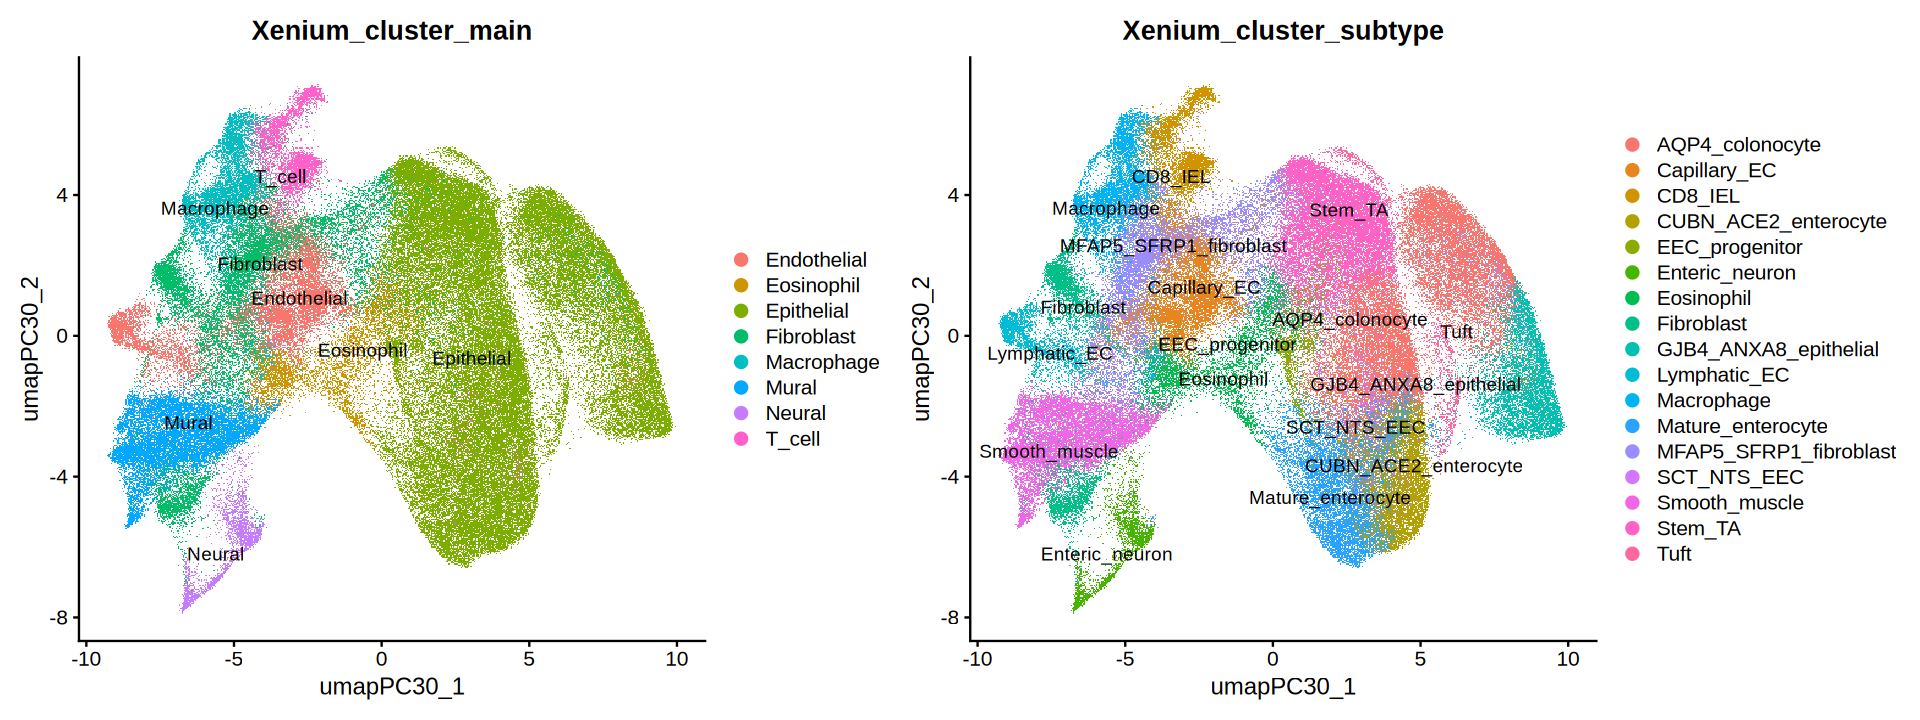

In [69]:
DimPlot(
  region_spatial,
  reduction = "umap_PC30",
  group.by = c("Xenium_cluster_main", "Xenium_cluster_subtype"),
  label = TRUE,
  repel = TRUE
)

In [70]:
options(repr.plot.width=16, repr.plot.height=16)

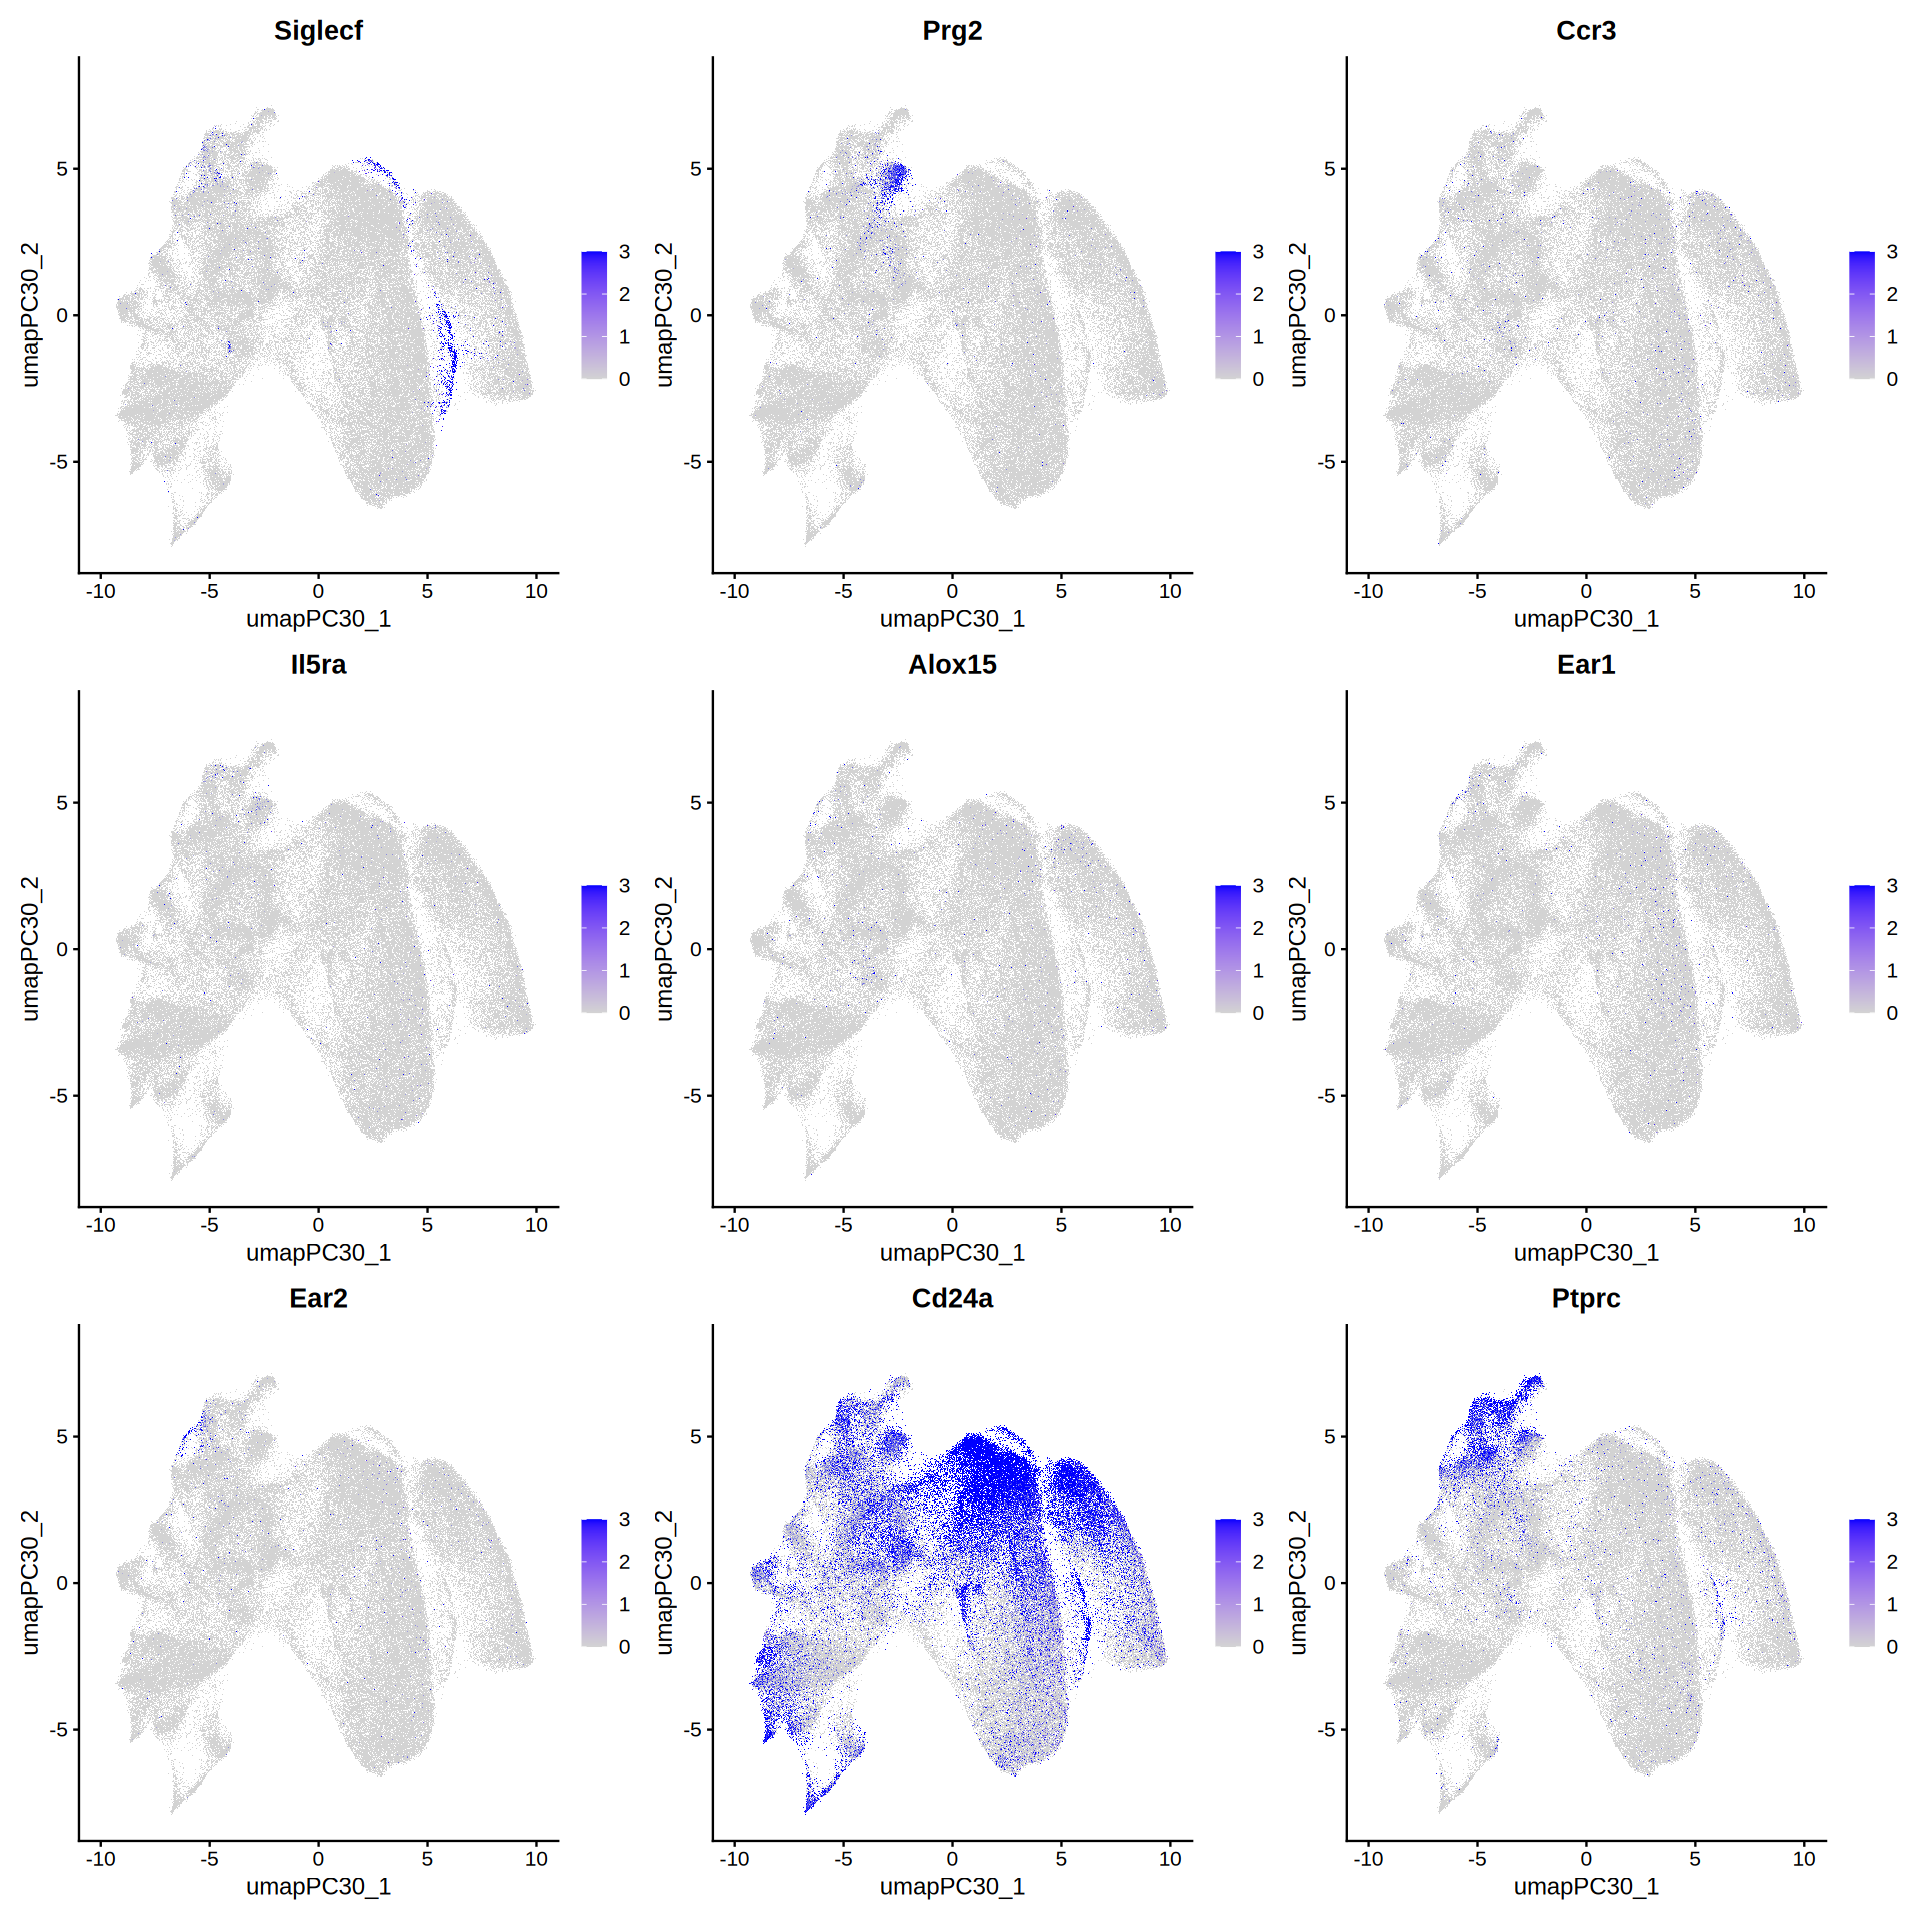

In [71]:
FeaturePlot(
    region_spatial,
    features = c(
        "Siglecf", "Prg2", "Ccr3",
        "Il5ra", "Alox15",
        "Ear1", "Ear2", "Cd24a", "Ptprc"
    ),
    reduction = "umap_PC30",
    raster = TRUE, 
    pt.size = 1, 
    max.cutoff = 3
)

In [72]:
celltype_table = unique(data.frame(region_spatial$cluster_res_0_8, region_spatial$Xenium_cluster_subtype))
celltype_table = celltype_table[order(as.numeric(celltype_table$region_spatial.cluster_res_0_8)),]
celltype_table

,region_spatial.cluster_res_0_8,region_spatial.Xenium_cluster_subtype
,<chr>,<chr>
aaaaoogd-1,1,Stem_TA
abgigfei-1,2,Smooth_muscle
aafeefbg-1,3,MFAP5_SFRP1_fibroblast
aadbkppe-1,4,AQP4_colonocyte
aaacfnak-1,5,AQP4_colonocyte
aaaglkje-1,6,Mature_enterocyte
acephmoc-1,7,Capillary_EC
aaagpmfl-1,8,CUBN_ACE2_enterocyte
aaidkjoo-1,9,GJB4_ANXA8_epithelial


In [73]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

## Step5 - Cell Type Annotation M2 - By Reference

In [74]:
region_spatial = readRDS(file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

In [75]:
Mayassi_REFERENCE_PATH <- file.path(
  "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data",
  "Mayassi_Nature2024_mouse",
  "scRNA_Seq",
  "Mayassi_Nature2024_ColonSPF.rds"
)

In [ ]:
colon_ref <- readRDS(Mayassi_REFERENCE_PATH)
DefaultAssay(colon_ref) <- "RNA"

In [77]:
cat("Anatomical regions:\n")
print(table(colon_ref$orig.ident))

Anatomical regions:

M001A M001B M001C M001D M003A M003B M003C M003D M005A M005B M005C M005D 
 7410  6370  7129  7746 11199 11677  7027 14007  8156  6628  8102 10462 


In [78]:
annotation_genes <- Reduce(
  intersect,
  list(
    FIX_GENESET,
    rownames(colon_ref),
    rownames(region_spatial)
  )
)

cat("Annotation features:", length(annotation_genes), "\n")

if (length(annotation_genes) < 100) {
  stop("Too few shared identity genes for reliable transfer; review gene symbols/panel.")
}

Annotation features: 465 


In [80]:
transfer_all <- run_Mayassi_transfer(
  reference = colon_ref,
  query = region_spatial,
  annotation_genes = annotation_genes,
  prefix = "RefAll"
)

RefAll: using 465 shared annotation genes

Warning message:
“Number of dimensions changing from 50 to 30”


In [81]:
region_spatial <- AddMetaData(
  region_spatial,
  metadata = transfer_all$main
)

region_spatial <- AddMetaData(
  region_spatial,
  metadata = transfer_all$subtype
)

In [117]:
subtype_to_main <- colon_ref@meta.data %>%
  select(
    CellType_subtype = HiRes,
    CellType_main = Lineage
  ) %>%
  filter(
    !is.na(CellType_subtype),
    !is.na(CellType_main)
  ) %>%
  distinct()

head(subtype_to_main)

,CellType_subtype,CellType_main
,<chr>,<chr>
GATGGAGTCTTTGCAT-1_1,Mature enterocytes I,enterocyte
TGTCCCATCCGCACGA-1_1,Immature enterocytes I,enterocyte
AGCCACGAGTCGCGAA-1_1,Stem/TA cells,enterocyte
AAACGCTTCGTCGATA-1_1,Hmgcs2+ non-canonical GCs,goblet
AGAAGTATCCCGTAAA-1_1,Muc3+ cycling GCs,goblet
CGAGGAAAGTTGCCTA-1_1,Muc3- cycling GCs,goblet


In [118]:
subtype_to_main_vec <- setNames(
  subtype_to_main$CellType_main,
  subtype_to_main$CellType_subtype
)

In [ ]:
region_spatial$RefAll_main_from_subtype <- subtype_to_main_vec[
  as.character(region_spatial$RefAll_subtype_predicted.id)
]

In [82]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial_passQC.rds")))

In [86]:
options(repr.plot.width=15, repr.plot.height=50)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



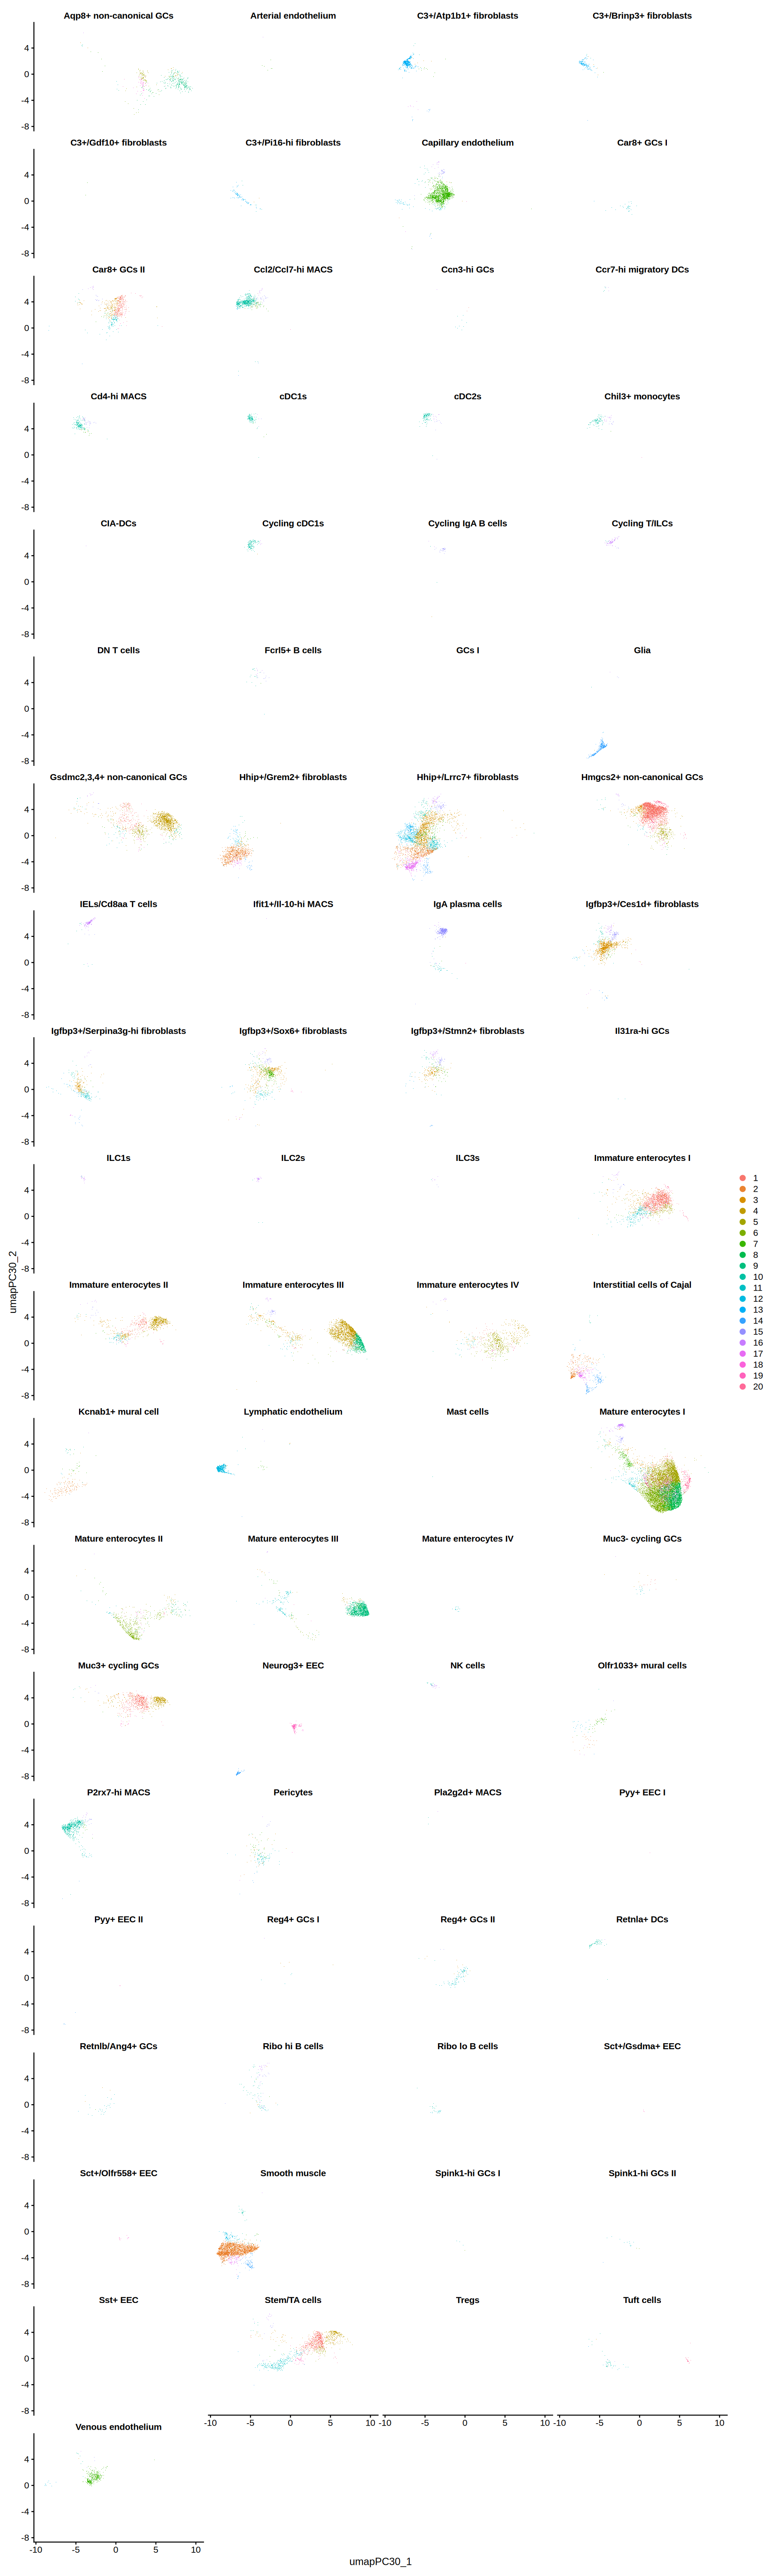

In [87]:
DimPlot(
  region_spatial,
  reduction = "umap_PC30",
  split.by = "RefAll_subtype_predicted.id",
  ncol=4
)

In [ ]:
options(repr.plot.width=15, repr.plot.height=15)

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


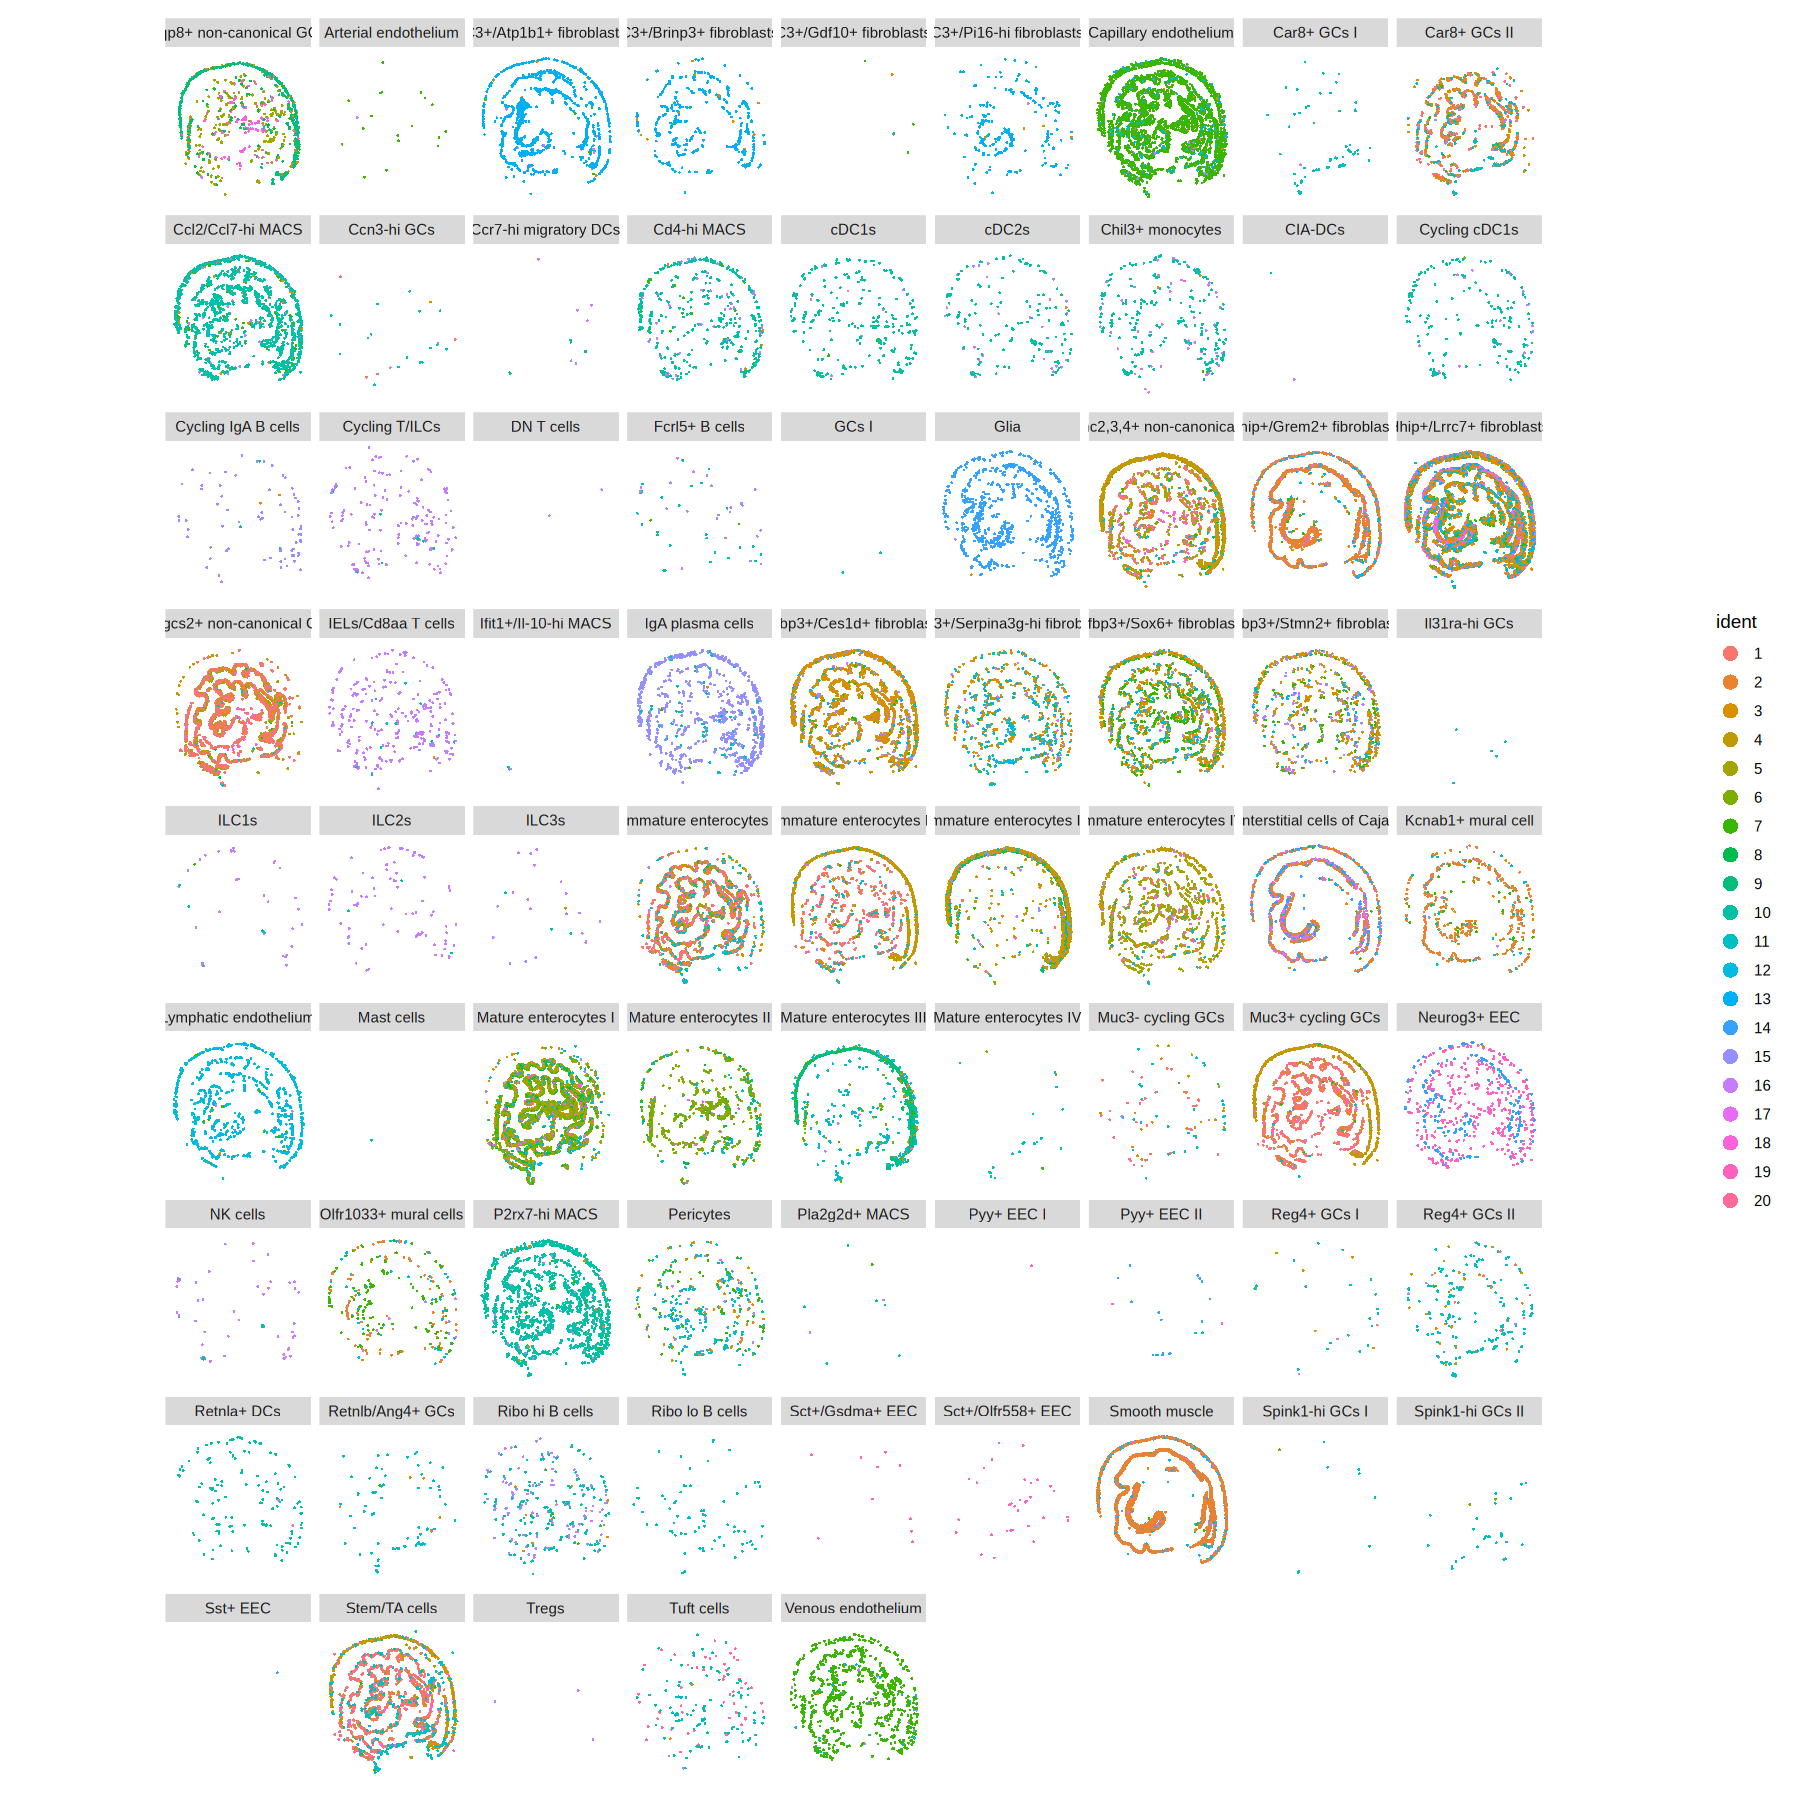

In [85]:
ImageDimPlot(
  region_spatial,
  fov = "fov",
  split.by = "RefAll_subtype_predicted.id",
  flip_xy = FALSE,
  dark.background = FALSE
)

In [110]:
options(repr.plot.width=16, repr.plot.height=12)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



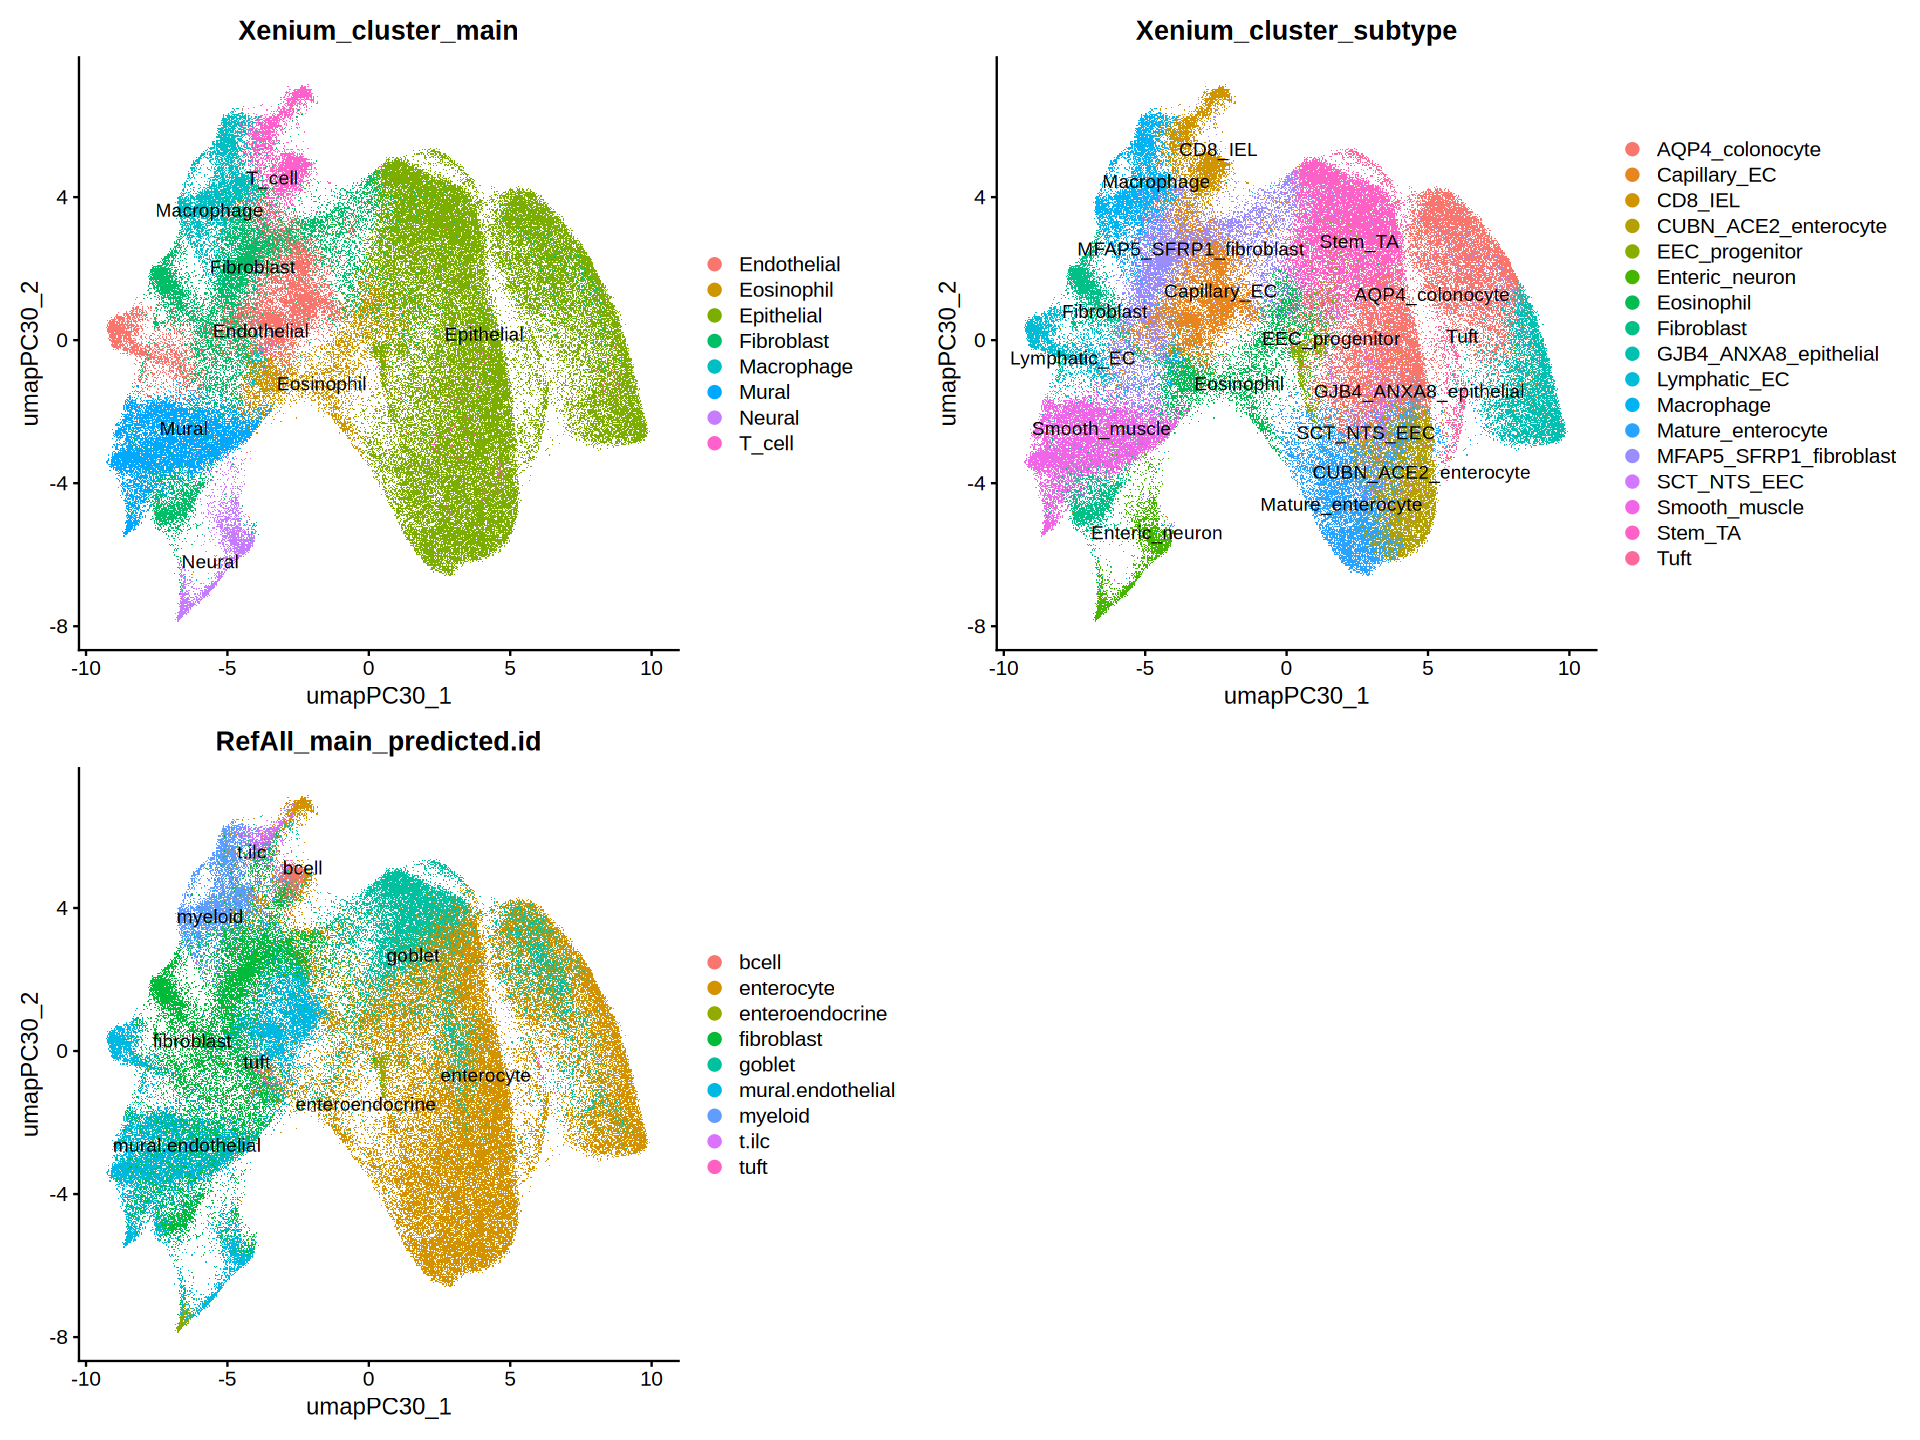

In [111]:
DimPlot(
  region_spatial,
  reduction = "umap_PC30",
  group.by = c("Xenium_cluster_main", "Xenium_cluster_subtype", "RefAll_main_predicted.id"),
  label = TRUE,
  repel = TRUE,
  ncol=2
)